# Diabetes Prediction Using Lifestyle Factors (NHANES 1999-2004)

## Project Overview
This project develops machine learning models to predict diabetes status using lifestyle and demographic data from the National Health and Nutrition Examination Survey (NHANES) 1999-2004. Unlike most diabetes studies that focus only on predicting diabetic vs. non-diabetic status, this project takes an innovative approach by:

1. First identifying individuals with diabetes
2. Then further classifying diabetic patients into Type 1 or Type 2 diabetes

The NHANES 1999-2004 dataset was specifically chosen because it includes C-peptide measurements, which are crucial for differentiating between Type 1 and Type 2 diabetes.

## Key Features
- **Data Source**: NHANES survey data (1999-2004)
- **Approach**: Two-stage classification model 
- **Target Variables**: 
  - Stage 1: Normal vs. Diabetic
  - Stage 2: Type 1 vs. Type 2 Diabetes
- **Features**: Demographics, laboratory tests, lifestyle factors (diet, physical activity, smoking, alcohol consumption)

## About NHANES
The National Health and Nutrition Examination Survey (NHANES) is a program of studies designed to assess the health and nutritional status of adults and children in the United States. The survey combines interviews and physical examinations from a nationally representative sample of approximately 5,000 people each year.

## 1. Importing Libraries

First, we'll import all necessary libraries for our analysis. This project uses a wide range of data science and machine learning libraries for data preprocessing, visualization, and model building.

In [5]:
# Use Python <= 3.10.11
import pandas as pd
import numpy as np
from typing import List, Dict
from sklearn.preprocessing import StandardScaler
from verstack import NaNImputer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifierCV
from sklearn.svm import LinearSVC, NuSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.inspection import permutation_importance
import joblib
pd.set_option('display.max_columns', None)

## 2. Data Preprocessing

### 2.1 Data Extraction and Integration

NHANES data is distributed across multiple files, with each file containing different aspects of the survey (laboratory tests, questionnaires, physical examinations, etc.) for different survey cycles.

| Component | Description | Data Type | Years |
|-----------|-------------|-----------|-------|
| Demographics (DEMO) | Basic participant information | Questionnaire | 1999-2004 |
| Body Measures (BMX) | Height, weight, BMI measurements | Examination | 1999-2004 |
| Laboratory Tests (L10AM, L10, L40, L13) | Blood tests including glucose, insulin, lipids | Laboratory | 1999-2004 |
| Dietary Interview (DRXTOT, DR1TOT, DR2TOT) | Nutrient intake information | Dietary Interview | 1999-2004 |
| Physical Activity (PAQ) | Exercise and activity questions | Questionnaire | 1999-2004 |
| Alcohol Use (ALQ) | Alcohol consumption patterns | Questionnaire | 1999-2004 |
| Smoking - Cigarette Use (SMQ) | Smoking history and current use | Questionnaire | 1999-2004 |
| Health Insurance (HIQ) | Insurance coverage information | Questionnaire | 1999-2004 |

The `combine_datasets` function below:
- Extracts specific variables from multiple NHANES files 
- Combines them based on respondent sequence number (SEQN)
- Handles column renaming for consistency across survey cycles

We take a first look at the dataset we will be working with

In [248]:
def combine_datasets(dataset_configs: List[Dict]) -> pd.DataFrame:
    """
    Combine multiple dataset groups into a single DataFrame.
    
    Args:
        dataset_configs: List of dictionaries containing dataset configurations
        Each dict should have:
            - prefix: prefix of the dataset files
            - suffixes: list of suffixes (e.g., ['D', 'E', 'F', 'G', 'H', 'I'])
            - columns: list of columns to extract (first one will be used as index)
            - column_names: dictionary mapping original column names to new names
            - folder: folder path where datasets are stored
    """
    combined_dfs = []
    
    for config in dataset_configs:
        # Generate file names
        files = [f"{config['prefix']}_{suffix}.xpt" for suffix in config['suffixes']]
        
        # Process each file in the current dataset group
        dfs = []
        for file in files:
            try:
                file_path = f"{config['folder']}/{file}"
                df = pd.read_sas(file_path, format='xport')[config['columns']]
                # Rename columns according to the mapping
                df.rename(columns=config['column_names'], inplace=True)
                dfs.append(df)
            except Exception as e:
                print(f"Error processing {file}: {str(e)}")
                continue
        
        if dfs:
            # Combine all files in the current group
            combined = pd.concat(dfs, axis=0)
            # Set the first column as index
            combined.set_index(config['columns'][0], inplace=True)
            combined_dfs.append(combined)
    
    # Join all dataset groups on the index
    final_df = pd.concat(combined_dfs, axis=1)
    return final_df

# Example usage:
dataset_configs = [
    {
        'prefix': 'L10AM',
        'suffixes': ['A', 'B', 'C'],
        'columns': ['SEQN', 'LBXGLU', 'LBXCPSI', 'LBXIN'],
        'column_names': {'LBXGLU': 'Fasting_Glucose', 'LBXCPSI': 'C_Peptide', 'LBXIN': 'Insulin'},
        'folder': './datasets/lab'
    },
    {
        'prefix': 'L10',
        'suffixes': ['A', 'B', 'C'],
        'columns': ['SEQN', 'LBXGH'],
        'column_names': {'LBXGH': 'Glycohemoglobin'},
        'folder': './datasets/lab'
    },
    {
        'prefix': 'L40',
        'suffixes': ['A', 'B', 'C'],
        'columns': ['SEQN', 'LBXSTR', 'LBXSUA'],
        'column_names': {'LBXSTR': 'Triglycerides', 'LBXSUA': 'Uric_Acid'},
        'folder': './datasets/lab'
    },
    {
        'prefix': 'L13',
        'suffixes': ['A', 'B'],
        'columns': ['SEQN', 'LBDHDL'],
        'column_names': {'LBDHDL': 'HDL_Cholesterol'},
        'folder': './datasets/lab'
    },
    {
        'prefix': 'L13',
        'suffixes': ['C'],
        'columns': ['SEQN', 'LBXHDD'],
        'column_names': {'LBXHDD': 'HDL_Cholesterol1'},
        'folder': './datasets/lab'
    },
    {
        'prefix': 'DEMO',
        'suffixes': ['A', 'B', 'C'],
        'columns': ['SEQN', 'RIDAGEYR', 'RIAGENDR', 'INDFMPIR'],
        'column_names': {'RIDAGEYR': 'Age', 'RIAGENDR': 'Gender', 'INDFMPIR': 'Poverty_Ratio'},
        'folder': './datasets/demo'
    },
    {
        'prefix': 'BMX',
        'suffixes': ['A', 'B', 'C'],
        'columns': ['SEQN', 'BMXBMI', 'BMXWT'],
        'column_names': {'BMXBMI': 'BMI', 'BMXWT': 'Weight'},
        'folder': './datasets/exam'
    },
    {
        'prefix': 'DRXTOT',
        'suffixes': ['A', 'B'],
        'columns': ['SEQN', 'DRXTPROT', 'DRXTCARB', 'DRXTCAFF', 'DRD320GW'],
        'column_names': {'DRXTPROT': 'Average_Protein', 'DRXTCARB': 'Average_Carbs', 'DRXTCAFF': 'Average_Coffee', 'DRD320GW': 'Average_Water'},
        'folder': './datasets/diet'
    },
    {
        'prefix': 'DR1TOT',
        'suffixes': ['C'],
        'columns': ['SEQN', 'DR1TPROT', 'DR1TCARB', 'DR1TCAFF', 'DR1TSUGR', 'DR1_320'],
        'column_names': {'DR1TPROT': 'Protein_Day1', 'DR1TCARB': 'Carb_Day1', 'DR1TCAFF': 'Coffee_Day1', 'DR1TSUGR':"Sugar_Day1", 'DR1_320': 'Water_Day1'},
        'folder': './datasets/diet'
    },
    {
        'prefix': 'DR2TOT',
        'suffixes': ['C'],
        'columns': ['SEQN', 'DR2TPROT', 'DR2TCARB', 'DR2TCAFF', 'DR2TSUGR', 'DR2_320'],
        'column_names': {'DR2TPROT': 'Protein_Day2', 'DR2TCARB': 'Carb_Day2', 'DR2TCAFF': 'Coffee_Day2', 'DR2TSUGR':'Sugar_Day2', 'DR2_320': 'Water_Day2'},
        'folder': './datasets/diet'
    },
    {
        'prefix': 'HIQ',
        'suffixes': ['A', 'B', 'C'],
        'columns': ['SEQN', 'HID010'],
        'column_names': {'HID010': 'Health_Insurance'},
        'folder': './datasets/questionaire'
    },
    {
        'prefix': 'PAQ',
        'suffixes': ['A', 'B', 'C'],
        'columns': ['SEQN', 'PAD020', 'PAQ050Q', 'PAQ050U', 'PAD200', 'PAD320', 'PAD440', 'PAD460'],
        'column_names':{'PAD020': 'Walk_or_Bicycle', 'PAQ050Q': 'Walk_or_Bicycle_Frequency', 'PAQ050U': 'Walk_or_Bicycle_Units', 'PAD200': 'Vigorous_Activity', 'PAD320': 'Moderate_Activity', 'PAD440': 'Workout', 'PAD460': 'Workout_Monthly_Frequency'},
        'folder': './datasets/questionaire'
    },
    {
        'prefix': 'ALQ',
        'suffixes': ['A'],
        'columns': ['SEQN', 'ALQ100', 'ALQ120Q', 'ALQ120U', 'ALQ130'],
        'column_names': {'ALQ100': 'Drink_Alcohol', 'ALQ120Q': 'Alcohol_Frequency', 'ALQ120U': 'Alcohol_Units', 'ALQ130': 'Alcohol_on_Average'},
        'folder': './datasets/questionaire'
    },
    {
        'prefix': 'ALQ',
        'suffixes': ['B'],
        'columns': ['SEQN', 'ALD100', 'ALQ120Q', 'ALQ120U', 'ALQ130'],
        'column_names': {'ALD100': 'Drink_Alcohol1', 'ALQ120Q': 'Alcohol_Frequency1', 'ALQ120U': 'Alcohol_Units1', 'ALQ130': 'Alcohol_on_Average1'},
        'folder': './datasets/questionaire'
    },
    {
        'prefix': 'ALQ',
        'suffixes': ['C'],
        'columns': ['SEQN', 'ALQ101', 'ALQ120Q', 'ALQ120U', 'ALQ130'],
        'column_names': {'ALQ101': 'Drink_Alcohol2', 'ALQ120Q': 'Alcohol_Frequency2', 'ALQ120U': 'Alcohol_Units2', 'ALQ130': 'Alcohol_on_Average2'},
        'folder': './datasets/questionaire'
    },
    {
        'prefix': 'SMQ',
        'suffixes': ['A', 'B'],
        'columns': ['SEQN', 'SMQ020','SMD030', 'SMQ040', 'SMQ050Q', 'SMQ050U', 'SMD057', 'SMD080', 'SMD090'],
        'column_names': {'SMQ020': 'Smoked_100_Cigs_in_life', 'SMD030': 'Age_Smoked_Regularly', 'SMQ040': 'Smoking_Status', 'SMQ050Q': 'How_long_You_Quit', 'SMQ050U': 'Unit_of_Quit', 'SMD057': 'Cigs_Smoked_Before_Quit', 'SMD080': 'Days_Smoked_In_Month', 'SMD090': 'Avg_Cigs_Per_Day_In_Month'},
        'folder': './datasets/questionaire'
    },
    {
        'prefix': 'SMQ',
        'suffixes': ['C'],
        'columns': ['SEQN', 'SMQ020','SMD030', 'SMQ040', 'SMQ050Q', 'SMQ050U', 'SMD057', 'SMD641', 'SMD650'],
        'column_names': {'SMQ020': 'Smoked_100_Cigs_in_life1', 'SMD030': 'Age_Smoked_Regularly1', 'SMQ040': 'Smoking_Status1', 'SMQ050Q': 'How_long_You_Quit1', 'SMQ050U': 'Unit_of_Quit1', 'SMD057': 'Cigs_Smoked_Before_Quit1', 'SMD641': 'Days_Smoked_In_Month1', 'SMD650': 'Avg_Cigs_Per_Day_In_Month1'},
        'folder': './datasets/questionaire'
    },
    
    # Add more dataset configurations as needed
]

def combine_columns(df):
    # Combine columns
    df['HDL_Cholesterol'] = df['HDL_Cholesterol'].combine_first(df['HDL_Cholesterol1'])
    df['Drink_Alcohol'] = df['Drink_Alcohol'].combine_first(df['Drink_Alcohol1'])
    df['Drink_Alcohol'] = df['Drink_Alcohol'].combine_first(df['Drink_Alcohol2'])
    df['Days_Smoked_In_Month'] = df['Days_Smoked_In_Month'].combine_first(df['Days_Smoked_In_Month1'])
    df['Avg_Cigs_Per_Day_In_Month'] = df['Avg_Cigs_Per_Day_In_Month'].combine_first(df['Avg_Cigs_Per_Day_In_Month1'])
    df['Age_Smoked_Regularly'] = df['Age_Smoked_Regularly'].combine_first(df['Age_Smoked_Regularly1'])
    df['Alcohol_Frequency'] = df['Alcohol_Frequency'].combine_first(df['Alcohol_Frequency1'])
    df['Alcohol_Frequency'] = df['Alcohol_Frequency'].combine_first(df['Alcohol_Frequency2'])
    df['Smoked_100_Cigs_in_life'] = df['Smoked_100_Cigs_in_life'].combine_first(df['Smoked_100_Cigs_in_life1'])
    df['Smoking_Status'] = df['Smoking_Status'].combine_first(df['Smoking_Status1'])
    df['How_long_You_Quit'] = df['How_long_You_Quit'].combine_first(df['How_long_You_Quit1'])
    df['Unit_of_Quit'] = df['Unit_of_Quit'].combine_first(df['Unit_of_Quit1'])
    df['Cigs_Smoked_Before_Quit'] = df['Cigs_Smoked_Before_Quit'].combine_first(df['Cigs_Smoked_Before_Quit1'])
    df['Alcohol_on_Average'] = df['Alcohol_on_Average'].combine_first(df['Alcohol_on_Average1'])
    df['Alcohol_on_Average'] = df['Alcohol_on_Average'].combine_first(df['Alcohol_on_Average2'])
    df['Alcohol_Units'] = df['Alcohol_Units'].combine_first(df['Alcohol_Units1'])
    df['Alcohol_Units'] = df['Alcohol_Units'].combine_first(df['Alcohol_Units2'])

    # Drop columns all at once
    columns_to_drop = [
        'HDL_Cholesterol1', 'Drink_Alcohol1', 'Drink_Alcohol2', 'Days_Smoked_In_Month1', 
        'Avg_Cigs_Per_Day_In_Month1', 'Age_Smoked_Regularly1', 'Alcohol_Frequency1', 
        'Alcohol_Frequency2', 'Smoked_100_Cigs_in_life1', 'Smoking_Status1', 
        'How_long_You_Quit1', 'Unit_of_Quit1', 'Cigs_Smoked_Before_Quit1', 
        'Alcohol_on_Average1', 'Alcohol_on_Average2',
        'Alcohol_Units1', 'Alcohol_Units2'
    ]

    df.drop(columns=columns_to_drop, inplace=True)

    return df

# Combine all datasets
df = combine_datasets(dataset_configs)
df = combine_columns(df)
print(df.info())
df.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 31126 entries, 2.0 to 31126.0
Data columns (total 46 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Fasting_Glucose            9645 non-null   float64
 1   C_Peptide                  9501 non-null   float64
 2   Insulin                    9501 non-null   float64
 3   Glycohemoglobin            19943 non-null  float64
 4   Triglycerides              19610 non-null  float64
 5   Uric_Acid                  19611 non-null  float64
 6   HDL_Cholesterol            23484 non-null  float64
 7   Age                        31126 non-null  float64
 8   Gender                     31126 non-null  float64
 9   Poverty_Ratio              28262 non-null  float64
 10  BMI                        26159 non-null  float64
 11  Weight                     28551 non-null  float64
 12  Average_Protein            18426 non-null  float64
 13  Average_Carbs              18426 non-null  floa

,Fasting_Glucose,C_Peptide,Insulin,Glycohemoglobin,Triglycerides,Uric_Acid,HDL_Cholesterol,Age,Gender,Poverty_Ratio,BMI,Weight,Average_Protein,Average_Carbs,Average_Coffee,Average_Water,Protein_Day1,Carb_Day1,Coffee_Day1,Sugar_Day1,Water_Day1,Protein_Day2,Carb_Day2,Coffee_Day2,Sugar_Day2,Water_Day2,Health_Insurance,Walk_or_Bicycle,Walk_or_Bicycle_Frequency,Walk_or_Bicycle_Units,Vigorous_Activity,Moderate_Activity,Workout,Workout_Monthly_Frequency,Drink_Alcohol,Alcohol_Frequency,Alcohol_Units,Alcohol_on_Average,Smoked_100_Cigs_in_life,Age_Smoked_Regularly,Smoking_Status,How_long_You_Quit,Unit_of_Quit,Cigs_Smoked_Before_Quit,Days_Smoked_In_Month,Avg_Cigs_Per_Day_In_Month
SEQN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2.00,83.70,0.48,4.55,4.70,115.00,6.10,54.00,77.00,1.00,5.00,24.90,75.40,123.16,350.37,530.45,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,2.00,NaN,NaN,3.00,3.00,1.00,60.00,1.00,24.00,3.00,1.00,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5.00,99.90,0.95,13.65,5.50,341.00,6.80,42.00,49.00,1.00,5.00,29.10,92.50,97.13,253.98,0.00,1298.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,2.00,NaN,NaN,1.00,1.00,1.00,4.00,1.00,4.00,1.00,3.00,1.00,0.00,3.00,5.00,3.00,NaN,NaN,NaN
7.00,85.60,0.55,9.72,5.80,57.00,4.30,105.00,59.00,2.00,NaN,29.39,78.00,81.50,224.95,293.29,236.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.00,1.00,2.00,1.00,2.00,NaN,2.00,NaN,NaN,NaN,1.00,17.00,3.00,20.00,4.00,20.00,NaN,NaN
8.00,84.20,0.34,7.63,5.00,29.00,5.20,67.00,13.00,1.00,0.53,15.51,40.70,236.80,774.61,50.61,590.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,1.00,6.00,2.00,1.00,2.00,1.00,12.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10.00,89.80,0.52,6.43,5.50,42.00,6.00,51.00,43.00,1.00,NaN,30.94,111.80,158.74,450.02,111.30,1888.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.00,3.00,1.00,9.00,9.00,2.00,NaN,1.00,6.00,3.00,1.00,1.00,16.00,1.00,NaN,NaN,NaN,30.00,10.00
11.00,95.90,0.65,11.99,5.20,72.00,7.10,40.00,15.00,1.00,1.25,22.00,65.00,212.55,729.38,313.61,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,2.00,NaN,NaN,1.00,1.00,1.00,9.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12.00,82.90,1.57,26.52,5.20,140.00,5.70,38.00,37.00,1.00,4.93,30.62,99.20,130.02,309.57,309.02,3304.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,2.00,NaN,NaN,2.00,1.00,2.00,NaN,1.00,2.00,2.00,3.00,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15.00,98.80,0.50,6.76,4.60,67.00,3.80,58.00,38.00,2.00,4.52,26.68,81.60,82.66,264.69,432.85,2478.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.00,2.00,3.00,1.00,1.00,2.00,NaN,1.00,4.00,1.00,2.00,1.00,14.00,1.00,NaN,NaN,NaN,30.00,15.00
20.00,90.60,0.50,7.84,4.70,110.00,2.70,43.00,23.00,2.00,3.03,23.68,59.80,97.82,205.70,37.20,811.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,2.00,NaN,NaN,2.00,1.00,2.00,NaN,1.00,3.00,1.00,3.00,1.00,12.00,3.00,4.00,2.00,NaN,NaN,NaN


### 2.2 Removing Duplicate Entries

After combining data from multiple sources, we need to check for and remove any duplicate entries to ensure data integrity.

In [249]:
def duplicates(df):
    df.drop_duplicates(inplace=True)
    return df


print(f"Duplicates rows dropped: {df.duplicated().sum()}\n\n")
df = duplicates(df)

Duplicates rows dropped: 119




### 2.3 Normalizing Questionnaire Responses

NHANES questionnaire data contains special response codes that need to be standardized for analysis:

| Response Type | Original Codes | New Value | Reason |
|---------------|----------------|-----------|--------|
| "Unable to" | 3 | 2 (No) | Participant did not perform the activity |
| "Refused" | 7, 77, 777, etc. | NaN | No valid data provided |
| "Don't know" | 9, 99, 999, etc. | NaN | No valid data provided |

This normalization ensures consistent interpretation of responses across different variables and survey cycles.

In [250]:
def normalization(df):
    # Normalize the data
    # Physical Activity Data https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/PAQ.htm
    df['Walk_or_Bicycle'] = df['Walk_or_Bicycle'].replace({3.0: 2})
    df['Vigorous_Activity'] = df['Vigorous_Activity'].replace({3.0: 2})
    df['Moderate_Activity'] = df['Moderate_Activity'].replace({3.0: 2})
    df['Workout'] = df['Workout'].replace({3.0: 2})
    
    # Insurances Data https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/HIQ.htm
    df['Health_Insurance'] = df['Health_Insurance'].replace({7.0: np.nan, 9.0: np.nan})

    # Smoking Data https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/SMQ.htm
    df['Smoked_100_Cigs_in_life'] = df['Smoked_100_Cigs_in_life'].replace({7.0: np.nan, 9.0: np.nan})
    df['Age_Smoked_Regularly'] = df['Age_Smoked_Regularly'].replace({777.0: np.nan, 999.0: np.nan})
    df['Smoking_Status'] = df['Smoking_Status'].replace({7.0: np.nan, 9.0: np.nan})
    df['How_long_You_Quit'] = df['How_long_You_Quit'].replace({77777.0: np.nan, 99999.0: np.nan})
    df['Unit_of_Quit'] = df['Unit_of_Quit'].replace({7.0: np.nan, 9.0: np.nan})
    df['Cigs_Smoked_Before_Quit'] = df['Cigs_Smoked_Before_Quit'].replace({777.0: np.nan, 999.0: np.nan})
    df['Days_Smoked_In_Month'] = df['Days_Smoked_In_Month'].replace({77.0: np.nan, 99.0: np.nan})
    df['Avg_Cigs_Per_Day_In_Month'] = df['Avg_Cigs_Per_Day_In_Month'].replace({777.0: np.nan, 999.0: np.nan})

    # Alcohol Data https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/ALQ.htm
    df['Drink_Alcohol'] = df['Drink_Alcohol'].replace({7.0: np.nan, 9.0: np.nan})
    df['Alcohol_Frequency'] = df['Alcohol_Frequency'].replace({777.0: np.nan, 999.0: np.nan})
    df['Alcohol_Units'] = df['Alcohol_Units'].replace({7.0: np.nan, 9.0: np.nan})
    df['Alcohol_on_Average'] = df['Alcohol_on_Average'].replace({77.0: np.nan, 99.0: np.nan})

    # Physical Activity Data https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/PAQ.htm
    df['Walk_or_Bicycle'] = df['Walk_or_Bicycle'].replace({7.0: np.nan, 9.0: np.nan})
    df['Walk_or_Bicycle_Frequency'] = df['Walk_or_Bicycle_Frequency'].replace({77777.0: np.nan, 99999.0: np.nan})
    df['Walk_or_Bicycle_Units'] = df['Walk_or_Bicycle_Units'].replace({7.0: np.nan, 9.0: np.nan})
    df['Vigorous_Activity'] = df['Vigorous_Activity'].replace({7.0: np.nan, 9.0: np.nan})
    df['Moderate_Activity'] = df['Moderate_Activity'].replace({7.0: np.nan, 9.0: np.nan})
    df['Workout'] = df['Workout'].replace({7.0: np.nan, 9.0: np.nan})
    df['Workout_Monthly_Frequency'] = df['Workout_Monthly_Frequency'].replace({7777.0: np.nan, 9999.0: np.nan})

    return df

df = normalization(df)

### 2.4 Processing Nutrient Data

#### Nutrient Variables in NHANES
| Original Variable | Description | Survey Years | Age Range |
|-------------------|-------------|--------------|-----------|
| DRXTPROT/DR1TPROT/DR2TPROT | Protein intake (gm) | 1999-2004 | All |
| DRXTCARB/DR1TCARB/DR2TCARB | Carbohydrate intake (gm) | 1999-2004 | All |
| DRXTCAFF/DR1TCAFF/DR2TCAFF | Caffeine intake (mg) | 1999-2004 | All |
| DRD320GW/DR1_320/DR2_320 | Water intake (gm) | 1999-2004 | All |
| DR1TSUGR/DR2TSUGR | Total sugars (gm) | 2003-2004 only | All |

NHANES collected dietary data differently across survey cycles:
- 1999-2002: Single average of nutrient intake 
- 2003-2004: Two separate days of nutrient measures

In [251]:
nutrients = ['Average_Protein', 'Average_Carbs', 'Average_Coffee', 'Average_Water', 'Protein_Day1', 'Carb_Day1', 'Coffee_Day1', 'Water_Day1', 'Protein_Day2', 'Carb_Day2', 'Coffee_Day2', 'Water_Day2']
df[nutrients].head(10)

,Average_Protein,Average_Carbs,Average_Coffee,Average_Water,Protein_Day1,Carb_Day1,Coffee_Day1,Water_Day1,Protein_Day2,Carb_Day2,Coffee_Day2,Water_Day2
SEQN,,,,,,,,,,,,
2.00,123.16,350.37,530.45,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5.00,97.13,253.98,0.00,1298.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7.00,81.50,224.95,293.29,236.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8.00,236.80,774.61,50.61,590.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10.00,158.74,450.02,111.30,1888.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11.00,212.55,729.38,313.61,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12.00,130.02,309.57,309.02,3304.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15.00,82.66,264.69,432.85,2478.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20.00,97.82,205.70,37.20,811.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We'll harmonize these differences to create consistent nutrient variables by calculating the averages across all survey years.

In [252]:
def nutrient_data(df):
    # Calculate average for Protein where both days have values


    # Calculate average for Carbs where both days have values
    df['Average_Carbs'] = df['Average_Carbs'].combine_first(df[['Carb_Day1', 'Carb_Day2']].mean(axis=1, skipna=False))

    # Calculate average for Sugar where both days have values
    df['Average_Coffee'] = df['Average_Coffee'].combine_first(df[['Coffee_Day1', 'Coffee_Day2']].mean(axis=1, skipna=False))

    # Calculate average for Water where both days have values
    df['Average_Water'] = df['Average_Water'].combine_first(df[['Water_Day1', 'Water_Day2']].mean(axis=1, skipna=False))

    # Calculate average for Protein where both days have values
    df['Average_Protein'] = df['Average_Protein'].combine_first(df[['Protein_Day1', 'Protein_Day2']].mean(axis=1, skipna=False))

    df['Average_Sugar'] = df[['Sugar_Day1', 'Sugar_Day2']].mean(axis=1, skipna=False)

    # Drop individual day columns after creating averages
    columns_to_drop = ['Carb_Day1', 'Carb_Day2', 
                    'Coffee_Day1', 'Coffee_Day2',
                    'Water_Day1', 'Water_Day2',
                    'Protein_Day1', 'Protein_Day2',
                    'Sugar_Day1', 'Sugar_Day2']
    df.drop(columns=columns_to_drop, inplace=True)

    return df

df = nutrient_data(df)
nutrients = ['Average_Protein', 'Average_Carbs', 'Average_Coffee', 'Average_Water', 'Average_Sugar']
df[nutrients].head(10)

,Average_Protein,Average_Carbs,Average_Coffee,Average_Water,Average_Sugar
SEQN,,,,,
2.00,123.16,350.37,530.45,0.00,NaN
5.00,97.13,253.98,0.00,1298.00,NaN
7.00,81.50,224.95,293.29,236.00,NaN
8.00,236.80,774.61,50.61,590.00,NaN
10.00,158.74,450.02,111.30,1888.00,NaN
11.00,212.55,729.38,313.61,0.00,NaN
12.00,130.02,309.57,309.02,3304.00,NaN
15.00,82.66,264.69,432.85,2478.00,NaN
20.00,97.82,205.70,37.20,811.25,NaN


### 2.5 Processing Physical Activity Data

#### Physical Activity Variables in NHANES
| Original Variable | Final Variable | Description | Eligible Age |
|-------------------|----------------|-------------|-------------|
| PAD020 | Walk_or_Bicycle | Walk or bicycle for transportation? | 16+ |
| PAQ050Q | Walk_or_Bicycle_Frequency | Number of times walk/bicycle | 16+ |
| PAQ050U | Walk_or_Bicycle_Units | Unit of measure (day/week/month) | 16+ |
| PAD200 | Vigorous_Activity | Vigorous activity in past 30 days? | 12+ |
| PAD320 | Moderate_Activity | Moderate activity in past 30 days? | 12+ |
| PAD440 | Workout | Muscle strengthening in past 30 days? | 16+ |
| PAD460 | Workout_Monthly_Frequency | Times per month strength training | 16+ |


In [253]:
activity = ['Walk_or_Bicycle', 'Walk_or_Bicycle_Frequency', 'Walk_or_Bicycle_Units', 'Vigorous_Activity', 'Moderate_Activity', 'Workout', 'Workout_Monthly_Frequency']
df[activity].head(10)

,Walk_or_Bicycle,Walk_or_Bicycle_Frequency,Walk_or_Bicycle_Units,Vigorous_Activity,Moderate_Activity,Workout,Workout_Monthly_Frequency
SEQN,,,,,,,
2.00,2.00,NaN,NaN,2.00,2.00,1.00,60.00
5.00,2.00,NaN,NaN,1.00,1.00,1.00,4.00
7.00,1.00,1.00,1.00,2.00,1.00,2.00,NaN
8.00,1.00,6.00,2.00,1.00,2.00,1.00,12.00
10.00,1.00,3.00,1.00,NaN,NaN,2.00,NaN
11.00,2.00,NaN,NaN,1.00,1.00,1.00,9.00
12.00,2.00,NaN,NaN,2.00,1.00,2.00,NaN
15.00,1.00,2.00,3.00,1.00,1.00,2.00,NaN
20.00,2.00,NaN,NaN,2.00,1.00,2.00,NaN


We'll standardize these measures by:
1. Converting all frequency measures to a monthly scale
2. Setting frequency to 0 for participants who reported no activity

In [254]:
def activity(df):
    
    
    # Create Walk_or Bicycle frequency column based on units
    def calculate_Walk_or_Bicycle_frequency(row):
        if pd.isna(row['Walk_or_Bicycle_Frequency']) or pd.isna(row['Walk_or_Bicycle_Units']):
            return np.nan
        
        frequency = row['Walk_or_Bicycle_Frequency']
        unit = row['Walk_or_Bicycle_Units']
        
        # Convert to yearly frequency
        if unit == 1:  # Daily
            return frequency * 30  # 30 days in a month
        elif unit == 2:  # Weekly
            return frequency * 4  # 4 weeks in a month
        elif unit == 3:  # Already Monthly
            return frequency
        else:
            return np.nan

    # Apply the calculation
    df['Walk_or_Bicycle_Monthly_Frequency'] = df.apply(calculate_Walk_or_Bicycle_frequency, axis=1)

    mask = df['Walk_or_Bicycle'] == 2 # No
    df.loc[mask, 'Walk_or_Bicycle_Monthly_Frequency'] = 0

    df.drop(columns=['Walk_or_Bicycle','Walk_or_Bicycle_Frequency', 'Walk_or_Bicycle_Units'], inplace=True)
    
    mask = df['Workout'] == 2 # No
    df.loc[mask, 'Workout_Monthly_Frequency'] = 0
    df.drop(columns=['Workout'], inplace=True)

    return df

df = activity(df)
activity = ['Walk_or_Bicycle_Monthly_Frequency', 'Vigorous_Activity', 'Moderate_Activity', 'Workout_Monthly_Frequency']
df[activity].head(10)

,Walk_or_Bicycle_Monthly_Frequency,Vigorous_Activity,Moderate_Activity,Workout_Monthly_Frequency
SEQN,,,,
2.00,0.00,2.00,2.00,60.00
5.00,0.00,1.00,1.00,4.00
7.00,30.00,2.00,1.00,0.00
8.00,24.00,1.00,2.00,12.00
10.00,90.00,NaN,NaN,0.00
11.00,0.00,1.00,1.00,9.00
12.00,0.00,2.00,1.00,0.00
15.00,2.00,1.00,1.00,0.00
20.00,0.00,2.00,1.00,0.00


### 2.6 Processing Alcohol Consumption Data

#### Alcohol Consumption Variables in NHANES
| Original Variable | Final Variable | Description | Eligible Age |
|-------------------|----------------|-------------|-------------|
| ALQ100/ALD100/ALQ101 | Drink_Alcohol | Whether participant drinks alcohol? | 20+ |
| ALQ120Q | Alcohol_Frequency | How often drinks alcohol (quantity) | 20+ |
| ALQ120U | Alcohol_Units | Unit of measure (day/week/month/year) | 20+ |
| ALQ130 | Alcohol_on_Average | Average drinks per day in past year | 20+ |


In [255]:
alcohol = ['Drink_Alcohol', 'Alcohol_Frequency', 'Alcohol_Units', 'Alcohol_on_Average']
df[alcohol].head(10)

,Drink_Alcohol,Alcohol_Frequency,Alcohol_Units,Alcohol_on_Average
SEQN,,,,
2.00,1.00,24.00,3.00,1.00
5.00,1.00,4.00,1.00,3.00
7.00,2.00,NaN,NaN,NaN
8.00,NaN,NaN,NaN,NaN
10.00,1.00,6.00,3.00,1.00
11.00,NaN,NaN,NaN,NaN
12.00,1.00,2.00,2.00,3.00
15.00,1.00,4.00,1.00,2.00
20.00,1.00,3.00,1.00,3.00


The alcohol questionnaire varied slightly across survey cycles. We'll standardize by:
1. Converting all frequency measures to a yearly scale
2. Setting alcohol metrics to 0 for non-drinkers

In [256]:
def alcohol(df):
   
   
    # Create yearly frequency column based on units
    def calculate_yearly_frequency(row):
        if pd.isna(row['Alcohol_Frequency']) or pd.isna(row['Alcohol_Units']):
            return np.nan
        
        frequency = row['Alcohol_Frequency']
        unit = row['Alcohol_Units']
        
        # Convert to yearly frequency
        if unit == 1:  # Weekly
            return frequency * 52  # 52 weeks in a year
        elif unit == 2:  # Monthly
            return frequency * 12  # 12 months in a year
        elif unit == 3:  # Already yearly
            return frequency
        else:
            return np.nan

    # Apply the calculation
    df['Alcohol_Yearly_Frequency'] = df.apply(calculate_yearly_frequency, axis=1)

    # Drop original columns
    df.drop(columns=['Alcohol_Frequency', 'Alcohol_Units'], inplace=True)

    mask = df['Drink_Alcohol'] == 2 # No
    df.loc[mask, 'Alcohol_Yearly_Frequency'] = 0
    df.loc[mask, 'Alcohol_on_Average'] = 0

    df.drop(columns=['Drink_Alcohol'], inplace=True)

    return df

df = alcohol(df)
alcohol = ['Alcohol_Yearly_Frequency', 'Alcohol_on_Average']
df[alcohol].head(10)

,Alcohol_Yearly_Frequency,Alcohol_on_Average
SEQN,,
2.00,24.00,1.00
5.00,208.00,3.00
7.00,0.00,0.00
8.00,NaN,NaN
10.00,6.00,1.00
11.00,NaN,NaN
12.00,24.00,3.00
15.00,208.00,2.00
20.00,156.00,3.00


### 2.7 Processing Smoking Data

#### Smoking Variables in NHANES
| Original Variable | Final Variable | Description | Eligible Age |
|-------------------|----------------|-------------|-------------|
| SMQ020 | Smoked_100_Cigs_in_life | Smoked at least 100 cigarettes? | 20+ |
| SMD030 | Age_Smoked_Regularly | Age started smoking regularly | 20+ (if smoker) |
| SMQ040 | Smoking_Status | Current smoking status | 20+ |
| SMQ050Q | How_long_You_Quit | Time since quitting (quantity) | 20+ (if quit) |
| SMQ050U | Unit_of_Quit | Unit for quit time (day/week/month/year) | 20+ (if quit) |
| SMD057 | Cigs_Smoked_Before_Quit | Cigarettes per day when quit | 20+ (if quit) |
| SMD080/SMD641 | Days_Smoked_In_Month | Days smoked in past 30 days | 20+ (if current) |
| SMD090/SMD650 | Avg_Cigs_Per_Day_In_Month | Average cigarettes per day | 20+ (if current) |

In [257]:
smoking = ['Smoked_100_Cigs_in_life', 'Age_Smoked_Regularly', 'Smoking_Status', 'How_long_You_Quit', 'Unit_of_Quit', 'Cigs_Smoked_Before_Quit', 'Days_Smoked_In_Month', 'Avg_Cigs_Per_Day_In_Month']
df[smoking].head(10)

,Smoked_100_Cigs_in_life,Age_Smoked_Regularly,Smoking_Status,How_long_You_Quit,Unit_of_Quit,Cigs_Smoked_Before_Quit,Days_Smoked_In_Month,Avg_Cigs_Per_Day_In_Month
SEQN,,,,,,,,
2.00,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5.00,1.00,0.00,3.00,5.00,3.00,NaN,NaN,NaN
7.00,1.00,17.00,3.00,20.00,4.00,20.00,NaN,NaN
8.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10.00,1.00,16.00,1.00,NaN,NaN,NaN,30.00,10.00
11.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12.00,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15.00,1.00,14.00,1.00,NaN,NaN,NaN,30.00,15.00
20.00,1.00,12.00,3.00,4.00,2.00,NaN,NaN,NaN


We'll standardize smoking variables by:
1. Converting quit duration to days for all participants
2. Creating logical rules for current smokers, former smokers, and never-smokers

In [258]:
def smoking(df):

    # Create yearly frequency column based on units
    def days_quit_smoking(row):
        if pd.isna(row['How_long_You_Quit']) or pd.isna(row['Unit_of_Quit']):
            return np.nan
        
        frequency = row['How_long_You_Quit']
        unit = row['Unit_of_Quit']
        
        # Convert daily frequency
        if unit == 4:  # Years
            return frequency * 365  # 365 days in a year
        elif unit == 3:  # Monthly
            return frequency * 30  # 30 days in a month
        elif unit == 2: #Weekly
            return frequency * 7 # 7 days in a week
        elif unit == 1:  # Already Daily
            return frequency
        else:
            return np.nan

    # Apply the calculation
    df['Days_Quit_Smoking'] = df.apply(days_quit_smoking, axis=1)

    # Drop original columns
    df.drop(columns=['How_long_You_Quit', 'Unit_of_Quit'], inplace=True)
   
    mask = df['Smoking_Status'] == 3 # Not current smoker
    df.loc[mask, 'Days_Smoked_In_Month'] = 0
    df.loc[mask, 'Avg_Cigs_Per_Day_In_Month'] = 0

    mask = (df['Smoking_Status'] == 1) | (df['Smoking_Status'] == 2) # Current smokers
    df.loc[mask, 'Days_Quit_Smoking'] = 0
    df.loc[mask, 'Cigs_Smoked_Before_Quit'] = 0

    mask = df['Smoked_100_Cigs_in_life'] == 2 # No
    df.loc[mask, 'Age_Smoked_Regularly'] = 0
    df.loc[mask, 'Days_Smoked_In_Month'] = 0
    df.loc[mask, 'Avg_Cigs_Per_Day_In_Month'] = 0
    df.loc[mask, 'Days_Quit_Smoking'] = 0
    df.loc[mask, 'Cigs_Smoked_Before_Quit'] = 0

    df.drop(columns=['Smoking_Status', 'Smoked_100_Cigs_in_life'], inplace=True)

    return df

df = smoking(df)
smoking = ['Days_Quit_Smoking', 'Age_Smoked_Regularly', 'Days_Smoked_In_Month', 'Avg_Cigs_Per_Day_In_Month']
df[smoking].head(10)

,Days_Quit_Smoking,Age_Smoked_Regularly,Days_Smoked_In_Month,Avg_Cigs_Per_Day_In_Month
SEQN,,,,
2.00,0.00,0.00,0.00,0.00
5.00,150.00,0.00,0.00,0.00
7.00,7300.00,17.00,0.00,0.00
8.00,NaN,NaN,NaN,NaN
10.00,0.00,16.00,30.00,10.00
11.00,NaN,NaN,NaN,NaN
12.00,0.00,0.00,0.00,0.00
15.00,0.00,14.00,30.00,15.00
20.00,28.00,12.00,0.00,0.00


### 2.8 Special Processing for Underage Participants

NHANES includes participants of all ages, but alcohol and smoking questionnaires were administered only to adults (typically 20+ years old). Let's identify underage participants and properly adjust their data.

In [259]:
underaged = df['Age'] < 20
print(f"UnderAged childeren: {sum(underaged)}\n\n")
print(df[underaged].info())

UnderAged childeren: 15707


<class 'pandas.core.frame.DataFrame'>
Index: 15707 entries, 8.0 to 31126.0
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Fasting_Glucose                    3076 non-null   float64
 1   C_Peptide                          3032 non-null   float64
 2   Insulin                            3031 non-null   float64
 3   Glycohemoglobin                    6447 non-null   float64
 4   Triglycerides                      6337 non-null   float64
 5   Uric_Acid                          6339 non-null   float64
 6   HDL_Cholesterol                    10201 non-null  float64
 7   Age                                15707 non-null  float64
 8   Gender                             15707 non-null  float64
 9   Poverty_Ratio                      14386 non-null  float64
 10  BMI                                12448 non-null  float64
 11  Weight                    

For underage participants (less than 20 years old), we'll set alcohol and smoking-related variables to 0 since these questionnaires were typically not administered to them.

In [260]:
def underaged(df):

    # Create a mask for rows where 'Age' is less than 20
    mask = df['Age'] < 20

    # List of alcohol and smoking-related columns
    alcohol_smoking_columns = [
        'Alcohol_on_Average', 'Alcohol_Yearly_Frequency', 'Days_Smoked_In_Month',
        'Avg_Cigs_Per_Day_In_Month', 'Days_Quit_Smoking', 'Cigs_Smoked_Before_Quit',
        'Age_Smoked_Regularly'
    ]

    # Set the values of these columns to 0 for rows where 'Age' is less than 20
    df.loc[mask, alcohol_smoking_columns] = 0

    return df

df = underaged(df)

### 2.9 Final Dataset Organization

To improve interpretability, we'll reorganize the columns in our dataset into logical groupings:

1. **Laboratory tests** (glucose, glycohemoglobin, insulin, C-peptide, lipids)
2. **Demographics** (gender, age, weight, BMI, poverty ratio, insurance)
3. **Nutrition** (protein, carbs, caffeine, water, sugar)
4. **Physical activity** (vigorous, moderate, workouts, walking/biking)  
5. **Alcohol consumption** (frequency, average drinks)
6. **Smoking** (age started, quit duration, cigarettes per day)

This organization makes the dataset more intuitive for analysis.

In [261]:
# ### Reording colunms for better interpretability and flow
def reorder(df):
    
    df = df[[
        'Fasting_Glucose', 'Glycohemoglobin', 'Insulin', 'C_Peptide', 'Triglycerides', 'Uric_Acid', 'HDL_Cholesterol',
        'Gender', 'Age', 'Weight', 'BMI', 'Poverty_Ratio', 'Health_Insurance',
        'Average_Protein', 'Average_Carbs', 'Average_Coffee', 'Average_Water', 'Average_Sugar',
        'Vigorous_Activity', 'Moderate_Activity', 'Workout_Monthly_Frequency', 'Walk_or_Bicycle_Monthly_Frequency',
        'Alcohol_on_Average', 'Alcohol_Yearly_Frequency',
        'Age_Smoked_Regularly', 'Days_Quit_Smoking', 'Cigs_Smoked_Before_Quit', 'Days_Smoked_In_Month', 'Avg_Cigs_Per_Day_In_Month'
    ]]

    return df

df = reorder(df)
df.head(10)

,Fasting_Glucose,Glycohemoglobin,Insulin,C_Peptide,Triglycerides,Uric_Acid,HDL_Cholesterol,Gender,Age,Weight,BMI,Poverty_Ratio,Health_Insurance,Average_Protein,Average_Carbs,Average_Coffee,Average_Water,Average_Sugar,Vigorous_Activity,Moderate_Activity,Workout_Monthly_Frequency,Walk_or_Bicycle_Monthly_Frequency,Alcohol_on_Average,Alcohol_Yearly_Frequency,Age_Smoked_Regularly,Days_Quit_Smoking,Cigs_Smoked_Before_Quit,Days_Smoked_In_Month,Avg_Cigs_Per_Day_In_Month
SEQN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2.00,83.70,4.70,4.55,0.48,115.00,6.10,54.00,1.00,77.00,75.40,24.90,5.00,1.00,123.16,350.37,530.45,0.00,NaN,2.00,2.00,60.00,0.00,1.00,24.00,0.00,0.00,0.00,0.00,0.00
5.00,99.90,5.50,13.65,0.95,341.00,6.80,42.00,1.00,49.00,92.50,29.10,5.00,1.00,97.13,253.98,0.00,1298.00,NaN,1.00,1.00,4.00,0.00,3.00,208.00,0.00,150.00,NaN,0.00,0.00
7.00,85.60,5.80,9.72,0.55,57.00,4.30,105.00,2.00,59.00,78.00,29.39,NaN,NaN,81.50,224.95,293.29,236.00,NaN,2.00,1.00,0.00,30.00,0.00,0.00,17.00,7300.00,20.00,0.00,0.00
8.00,84.20,5.00,7.63,0.34,29.00,5.20,67.00,1.00,13.00,40.70,15.51,0.53,2.00,236.80,774.61,50.61,590.00,NaN,1.00,2.00,12.00,24.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
10.00,89.80,5.50,6.43,0.52,42.00,6.00,51.00,1.00,43.00,111.80,30.94,NaN,1.00,158.74,450.02,111.30,1888.00,NaN,NaN,NaN,0.00,90.00,1.00,6.00,16.00,0.00,0.00,30.00,10.00
11.00,95.90,5.20,11.99,0.65,72.00,7.10,40.00,1.00,15.00,65.00,22.00,1.25,1.00,212.55,729.38,313.61,0.00,NaN,1.00,1.00,9.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
12.00,82.90,5.20,26.52,1.57,140.00,5.70,38.00,1.00,37.00,99.20,30.62,4.93,1.00,130.02,309.57,309.02,3304.00,NaN,2.00,1.00,0.00,0.00,3.00,24.00,0.00,0.00,0.00,0.00,0.00
15.00,98.80,4.60,6.76,0.50,67.00,3.80,58.00,2.00,38.00,81.60,26.68,4.52,1.00,82.66,264.69,432.85,2478.00,NaN,1.00,1.00,0.00,2.00,2.00,208.00,14.00,0.00,0.00,30.00,15.00
20.00,90.60,4.70,7.84,0.50,110.00,2.70,43.00,2.00,23.00,59.80,23.68,3.03,2.00,97.82,205.70,37.20,811.25,NaN,2.00,1.00,0.00,0.00,3.00,156.00,12.00,28.00,NaN,0.00,0.00


### 2.10 Laboratory Data Processing and Diabetes Classification

#### Laboratory Variables for Diabetes Classification
| Variable | Description | Role in Classification |
|----------|-------------|------------------------|
| Fasting_Glucose | Fasting blood glucose (mg/dL) | Primary diagnostic marker |
| Glycohemoglobin | HbA1c (%) | Primary diagnostic marker |
| Insulin | Fasting insulin (uU/mL) | Type differentiation |
| C_Peptide | C-peptide (pmol/mL) | Key for Type 1 vs Type 2 |
| Triglycerides | Triglycerides (mg/dL) | Metabolic risk marker |
| Uric_Acid | Uric acid (mg/dL) | Metabolic risk marker |
| HDL_Cholesterol | HDL cholesterol (mg/dL) | Metabolic risk marker |

In [262]:
lab_data_columns = ['Fasting_Glucose', 'Glycohemoglobin', 'Insulin', 'C_Peptide', 'Triglycerides', 'Uric_Acid', 'HDL_Cholesterol']
df[lab_data_columns].head(10)

,Fasting_Glucose,Glycohemoglobin,Insulin,C_Peptide,Triglycerides,Uric_Acid,HDL_Cholesterol
SEQN,,,,,,,
2.00,83.70,4.70,4.55,0.48,115.00,6.10,54.00
5.00,99.90,5.50,13.65,0.95,341.00,6.80,42.00
7.00,85.60,5.80,9.72,0.55,57.00,4.30,105.00
8.00,84.20,5.00,7.63,0.34,29.00,5.20,67.00
10.00,89.80,5.50,6.43,0.52,42.00,6.00,51.00
11.00,95.90,5.20,11.99,0.65,72.00,7.10,40.00
12.00,82.90,5.20,26.52,1.57,140.00,5.70,38.00
15.00,98.80,4.60,6.76,0.50,67.00,3.80,58.00
20.00,90.60,4.70,7.84,0.50,110.00,2.70,43.00


Using clinical guidelines adapted for available biomarkers, we'll classify participants into:
1. **Normal**: Fasting glucose < 126 mg/dL AND HbA1c < 6.5%
2. **Type 1 Diabetes**: Diabetic with low C-peptide levels and other T1D markers
3. **Type 2 Diabetes**: Diabetic with normal/high C-peptide and metabolic markers

<img src='diabetes_image.png'>

This classification approach mimics clinical decision-making while using available data.
We'll ensure all laboratory data have no missing values by dropping rows with missing(NaN) in them.

In [263]:
def classification(df):
   
    """
    Classify patients into `Normal`, `Type_1`, and `Type_2` diabetes based on lab data.
        
        Expected DataFrame columns:
        - "Fasting Glucose"  : Fasting Plasma Glucose (mg/dL)
        - "Glycohemoglobin"       : HbA1c (%)
        - "Insulin"          : Fasting insulin (µU/mL)
        - "C-Peptide"        : Fasting C-peptide (ng/mL)
        - "Triglycerides"    : Triglycerides (mg/dL)
        - "Uric Acid"        : Uric Acid (mg/dL)
        - "HDL_Cholesterol"  : HDL Cholesterol (mg/dL)
    """


    # Define the subset of lab data columns
    lab_data_columns = ['Fasting_Glucose', 'Glycohemoglobin', 'Insulin', 'C_Peptide', 'Triglycerides', 'Uric_Acid', 'HDL_Cholesterol']

    # Drop rows with NaN values in the subset of lab data columns
    df.dropna(subset=lab_data_columns, inplace=True)


    # #### Classification of diabetes to `Normal`, `Type_1` and `Type_2`

    # %%
    def classify_patient(row):

        # --- Step 1: Glycemic Diagnosis ---
        fpg = row['Fasting_Glucose']
        hba1c = row['Glycohemoglobin']  # assumed to be HbA1c

        # ADA thresholds:
        # Diabetes: FPG >= 126 mg/dL or HbA1c >= 6.5%
        if (fpg < 126) and (hba1c < 6.5):
            return 'Normal'

        # --- Step 2: Diabetes Subtype Classification Using C_Peptide
        c_peptide = row['C_Peptide']
        # Illustrative thresholds:
        type1_cp_thresh = 0.5  # ng/mL
        type2_cp_thresh = 1.0  # ng/mL
        
        if c_peptide < type1_cp_thresh:
            return 'Type_1'
        elif c_peptide >= type2_cp_thresh:
            return 'Type_2'
        # If ambiguous (0.5 <= c_peptide < 1.0), proceed to additional markers.

        # --- Step 3: Composite Scoring Using Insulin and HOMA-IR ---

        # Set scores (you can adjust these weights based on validation):
        score_type1 = 0
        score_type2 = 0

        # Mild favoring of type 2 if higher in ambiguous range, type 1 if lower
        if c_peptide < 0.75:
            score_type1 += 1
        elif c_peptide >= 0.75:
            score_type2 += 1

        # Evaluate Insulin:
        insulin = row['Insulin']

        # Low insulin (< 5 µU/mL) favors type 1
        # High insulin (>= 10 µU/mL) favors type 2
        if insulin < 5:
            score_type1 += 1
        elif insulin >= 10:
            score_type2 += 1

        # Evaluate HOMA-IR:
        homa_ir = (insulin * fpg) / 405

        # Low HOMA-IR (< 1.5) favors type 1
        # High HOMA-IR (>= 2.5) favors type 2
        if homa_ir < 1.5:
            score_type1 += 1
        elif homa_ir >= 2.5:
            score_type2 += 1

        # --- Step 4: Consider Additional Metabolic Markers (Optional) ---
        metabolic_score = 0
        if row['Triglycerides'] >= 150:
            metabolic_score += 1
        if row['Uric_Acid'] >= 6.5:
            metabolic_score += 1
        if row['HDL_Cholesterol'] < 40:
            metabolic_score += 1

        # A higher metabolic risk score is more consistent with type 2 diabetes.
        if metabolic_score >= 2:
            score_type2 += 1
        else:
            score_type1 += 1

        # --- Step 5: Final Classification Decision ---
        # Use a simple comparison of scores:
        if score_type1 > score_type2:
            return 'Type_1'
        elif score_type2 > score_type1:
            return 'Type_2'
        else:
            # In case of a tie, default to clinical judgment; here we choose Type_2 as more common.
            return 'Type_2'

    # Apply the classification function to each row.
    df["Classification"] = df.apply(classify_patient, axis=1)

    
    # Drop all laboratory columns
    df.drop(columns=lab_data_columns, inplace=True)

    return df


df = classification(df)
print(df['Classification'].value_counts())
df[['Classification']].head(10)

Classification
Normal    8705
Type_2     627
Type_1     128
Name: count, dtype: int64


,Classification
SEQN,
2.00,Normal
5.00,Normal
7.00,Normal
8.00,Normal
10.00,Normal
11.00,Normal
12.00,Normal
15.00,Normal
20.00,Normal


### 2.11 Missing Data Imputation

After classification, we need to prepare our dataset for modeling by handling missing values:

1. First, we'll convert categorical variables to numeric:
   - Classification: Normal (0), Type 1 (1), Type 2 (2)
   - Gender: Female (0), Male (1)
   - Activity variables: No (0), Yes (1)
   
2. We'll ensure core variables have no missing values by dropping rows with missing:
   - Gender, Age, Weight, BMI (fundamental demographic data)
   
3. We'll use Verstack's NaNImputer for intelligent imputation of remaining missing values
   - Modified threshold to 90% to retain Average_Sugar

In [264]:
def imputation(df):
    # Impute missing values
    df['Classification'] = df['Classification'].replace({'Normal': 0, 'Type_1': 1, 'Type_2': 2})
    df['Gender'] = df['Gender'].replace({2: 0})
    df['Moderate_Activity'] = df['Moderate_Activity'].replace({2: 0})
    df['Vigorous_Activity'] = df['Vigorous_Activity'].replace({2: 0})
    df['Health_Insurance'] = df['Health_Insurance'].replace({2: 0})

    df.dropna(subset=['Gender', 'Age', 'Weight', 'BMI'], inplace=True)

    # initialize with default parameters
    imputer = NaNImputer()

    df_features = df.drop(columns=['Classification'])
    df_features = imputer.impute(df_features)

    df = df_features.join(df['Classification'])

    return df

df = imputation(df)


 * Initiating NaNImputer.impute
     . Dataset dimensions:
     .. rows:         9277
     .. columns:      22
     .. mb in memory: 1.63
     .. NaN cols num: 18

   - Drop hopeless NaN cols

   - Processing whole data for imputation

   - Imputing single core 18 cols
     . Imputed (regression) - 798      NaN in Poverty_Ratio
     . Imputed (  binary  ) - 115      NaN in Health_Insurance
     . Imputed (regression) - 459      NaN in Average_Protein
     . Imputed (regression) - 459      NaN in Average_Carbs
     . Imputed (regression) - 459      NaN in Average_Coffee
     . Imputed (regression) - 464      NaN in Average_Water
     . Imputed (regression) - 6537     NaN in Average_Sugar
     . Imputed (  binary  ) - 73       NaN in Vigorous_Activity
     . Imputed (  binary  ) - 78       NaN in Moderate_Activity
     . Imputed (regression) - 74       NaN in Workout_Monthly_Frequency
     . Imputed (regression) - 71       NaN in Walk_or_Bicycle_Monthly_Frequency
     . Imputed (multicl

In [265]:
print(df.info())    
df.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 9277 entries, 2.0 to 31124.0
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             9277 non-null   float64
 1   Age                                9277 non-null   float64
 2   Weight                             9277 non-null   float64
 3   BMI                                9277 non-null   float64
 4   Poverty_Ratio                      9277 non-null   float64
 5   Health_Insurance                   9277 non-null   float64
 6   Average_Protein                    9277 non-null   float64
 7   Average_Carbs                      9277 non-null   float64
 8   Average_Coffee                     9277 non-null   float64
 9   Average_Water                      9277 non-null   float64
 10  Average_Sugar                      9277 non-null   float64
 11  Vigorous_Activity                  9277 non-null   float

,Gender,Age,Weight,BMI,Poverty_Ratio,Health_Insurance,Average_Protein,Average_Carbs,Average_Coffee,Average_Water,Average_Sugar,Vigorous_Activity,Moderate_Activity,Workout_Monthly_Frequency,Walk_or_Bicycle_Monthly_Frequency,Alcohol_on_Average,Alcohol_Yearly_Frequency,Age_Smoked_Regularly,Days_Quit_Smoking,Cigs_Smoked_Before_Quit,Days_Smoked_In_Month,Avg_Cigs_Per_Day_In_Month,Classification
SEQN,,,,,,,,,,,,,,,,,,,,,,,
2.00,1.00,77.00,75.40,24.90,5.00,1.00,123.16,350.37,530.45,0.00,139.78,0.00,0.00,60.00,0.00,1.00,24.00,0.00,0.00,0.00,0.00,0.00,0
5.00,1.00,49.00,92.50,29.10,5.00,1.00,97.13,253.98,0.00,1298.00,100.45,1.00,1.00,4.00,0.00,3.00,208.00,0.00,150.00,13.43,0.00,0.00,0
7.00,0.00,59.00,78.00,29.39,2.06,1.00,81.50,224.95,293.29,236.00,94.94,0.00,1.00,0.00,30.00,0.00,0.00,17.00,7300.00,20.00,0.00,0.00,0
8.00,1.00,13.00,40.70,15.51,0.53,0.00,236.80,774.61,50.61,590.00,378.69,1.00,0.00,12.00,24.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0
10.00,1.00,43.00,111.80,30.94,3.17,1.00,158.74,450.02,111.30,1888.00,239.32,0.00,0.00,0.00,90.00,1.00,6.00,16.00,0.00,0.00,30.00,10.00,0
11.00,1.00,15.00,65.00,22.00,1.25,1.00,212.55,729.38,313.61,0.00,378.57,1.00,1.00,9.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0
12.00,1.00,37.00,99.20,30.62,4.93,1.00,130.02,309.57,309.02,3304.00,132.45,0.00,1.00,0.00,0.00,3.00,24.00,0.00,0.00,0.00,0.00,0.00,0
15.00,0.00,38.00,81.60,26.68,4.52,1.00,82.66,264.69,432.85,2478.00,105.67,1.00,1.00,0.00,2.00,2.00,208.00,14.00,0.00,0.00,30.00,15.00,0
20.00,0.00,23.00,59.80,23.68,3.03,0.00,97.82,205.70,37.20,811.25,75.35,0.00,1.00,0.00,0.00,3.00,156.00,12.00,28.00,21.62,0.00,0.00,0


### 2.12 Final Data Type Normalization

As a final preprocessing step, we'll standardize the data types for all variables and ensure values are in appropriate ranges:

1. Convert categorical/binary variables to integers
2. Convert continuous variables to floats with standard decimal notation

In [266]:
def datatype_normalization(df):

    def convert_scientific_to_float(df, float_columns):
        """
        Convert all float columns from scientific notation to numerical format
        
        Args:
            df: pandas DataFrame
        
        Returns:
            DataFrame with converted float columns
        """
        # Convert each float column
        for column in float_columns:
            try:
                # Convert to numeric ensuring float type
                df[column] = pd.to_numeric(df[column], errors='coerce')
                
                # Format to display regular decimal notation instead of scientific
                # You can adjust the number of decimal places by changing the .2f
                df[column] = df[column].map('{:.2f}'.format).astype(float)
            
            except Exception as e:
                print(f"Error converting {column}: {str(e)}")
        
        return df

    # Assuming you already have your DataFrame
    float_columns = ['Weight', 'BMI', 'Poverty_Ratio', 'Average_Protein', 'Average_Carbs', 'Average_Coffee', 'Average_Water', 'Average_Sugar']
    int_columns = df.columns.difference(float_columns)
    df[int_columns] = df[int_columns].astype(int)
    df = convert_scientific_to_float(df, float_columns)

    # Replace all negative values with 0
    df[df < 0] = 0

    return df

df = datatype_normalization(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9277 entries, 2.0 to 31124.0
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             9277 non-null   int32  
 1   Age                                9277 non-null   int32  
 2   Weight                             9277 non-null   float64
 3   BMI                                9277 non-null   float64
 4   Poverty_Ratio                      9277 non-null   float64
 5   Health_Insurance                   9277 non-null   int32  
 6   Average_Protein                    9277 non-null   float64
 7   Average_Carbs                      9277 non-null   float64
 8   Average_Coffee                     9277 non-null   float64
 9   Average_Water                      9277 non-null   float64
 10  Average_Sugar                      9277 non-null   float64
 11  Vigorous_Activity                  9277 non-null   int32

Let's examine the range of values for each variable to confirm our processing:

In [267]:
# Generate the range of values for each column
column_ranges = df.describe().T[['min', 'max']]

# Display the ranges
print(column_ranges)

                                    min      max
Gender                             0.00     1.00
Age                               12.00    85.00
Weight                            27.50   209.10
BMI                               13.72    66.44
Poverty_Ratio                      0.00     5.00
Health_Insurance                   0.00     1.00
Average_Protein                    0.00   718.42
Average_Carbs                     13.17  1700.37
Average_Coffee                     0.00  4159.92
Average_Water                      0.00 12390.00
Average_Sugar                      2.07   596.45
Vigorous_Activity                  0.00     1.00
Moderate_Activity                  0.00     1.00
Workout_Monthly_Frequency          0.00   999.00
Walk_or_Bicycle_Monthly_Frequency  0.00   300.00
Alcohol_on_Average                 0.00    30.00
Alcohol_Yearly_Frequency           0.00   365.00
Age_Smoked_Regularly               0.00    74.00
Days_Quit_Smoking                  0.00 27375.00
Cigs_Smoked_Before_Q

## 3. Exploratory Data Analysis

Let's explore relationships between our variables using a correlation matrix heatmap. This visualization will help us:
1. Identify variables strongly associated with diabetes classification
2. Understand relationships between different lifestyle factors
3. Detect potential multicollinearity between predictors

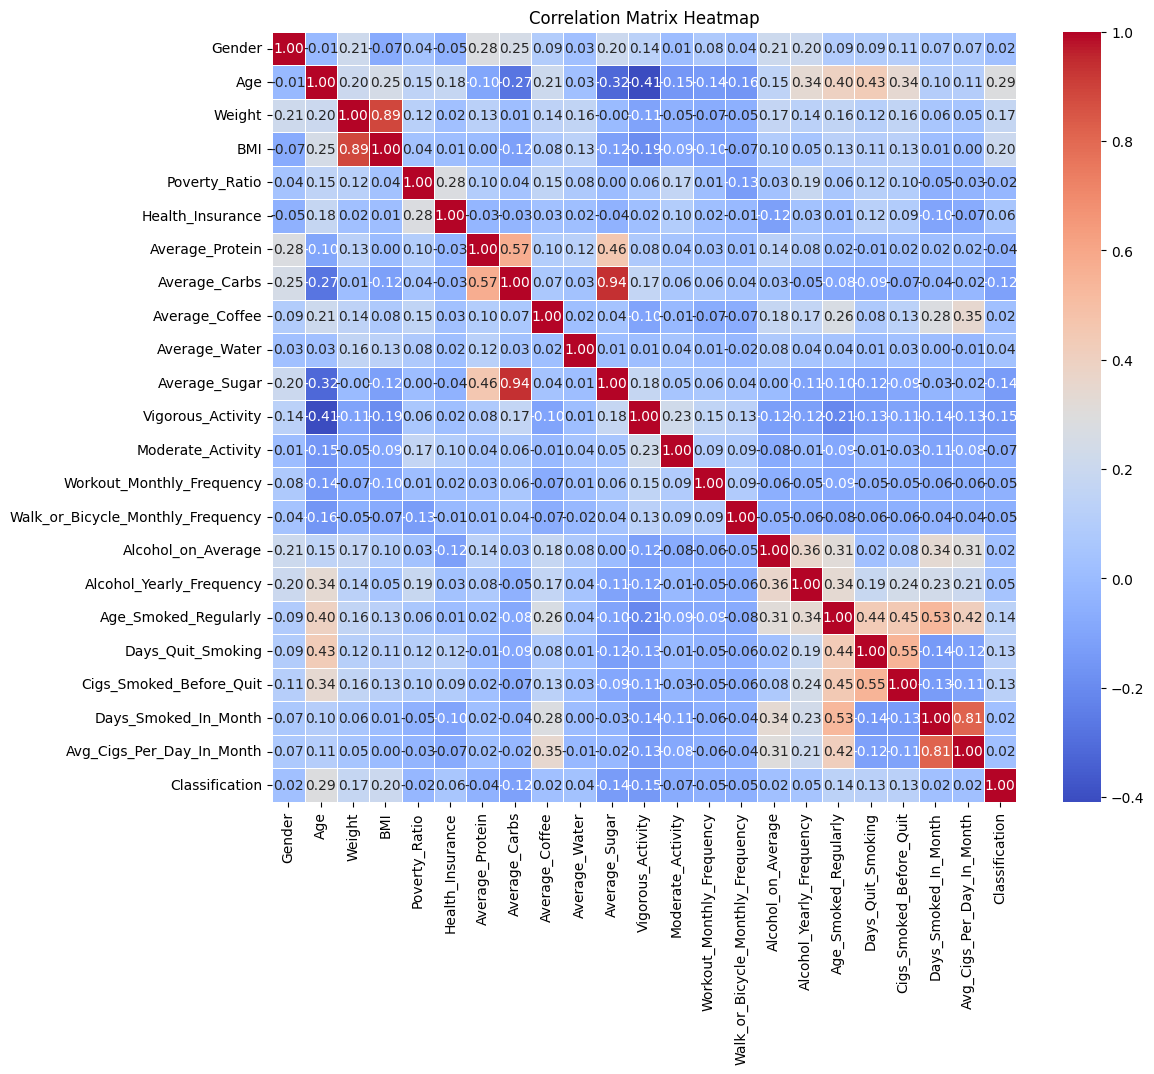

In [268]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)

# Set the title
plt.title('Correlation Matrix Heatmap')

# Show the plot
plt.show()

In [269]:
df.to_csv('diabetes_data.csv', index=False)

## 4. Model Development

Our modeling approach involves tackling the diabetes classification problem through a thoughtful process:

1. **Initial Model Evaluation**: Using LazyPredict to identify promising algorithms
2. **Data Balancing Exploration**: Testing different approaches to handle class imbalance
3. **Binary Problem Decomposition**: Breaking the problem into two separate binary tasks
4. **Advanced Data Balancing with SMOTE**: Applying synthetic oversampling to improve model performance
5. **Ensemble Model Construction**: Combining top-performing models for optimal results

Throughout our model development process, we'll focus on **balanced accuracy** as our primary evaluation metric instead of traditional accuracy. This choice is crucial because:

- Our dataset is imbalanced (many more "Normal" samples than diabetic samples)
- Traditional accuracy can be misleading with imbalanced data (a model could achieve high accuracy by simply predicting the majority class)
- Balanced accuracy averages the recall obtained on each class, giving equal importance to all classes regardless of their frequency

Let's begin by evaluating a wide range of classification algorithms using LazyPredict.

### 4.1 Initial Model Evaluation with LazyPredict

We'll use LazyPredict to quickly test multiple classification algorithms and identify those with the most promising performance on our diabetes classification task:

In [270]:
df = pd.read_csv('diabetes_data.csv')
X = df.drop('Classification', axis=1)
y = df['Classification']

# Split the dataset
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=random_state)

#Use standard scaler on the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# Fit the classifier on the training data and evaluate on the test data
models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)

# Display the top 5 models based on accuracy
print(y.value_counts())
models.sort_values('Balanced Accuracy', ascending=False).head(len(models))

  0%|          | 0/31 [00:00<?, ?it/s]

Classification
0    8553
2     599
1     125
Name: count, dtype: int64


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
NearestCentroid,0.65,0.56,None,0.74,0.13
GaussianNB,0.77,0.52,None,0.82,0.08
QuadraticDiscriminantAnalysis,0.80,0.52,None,0.84,0.23
BernoulliNB,0.84,0.42,None,0.86,0.15
LabelSpreading,0.87,0.40,None,0.87,14.01
LabelPropagation,0.87,0.40,None,0.87,9.90
Perceptron,0.88,0.39,None,0.87,0.32
ExtraTreeClassifier,0.86,0.38,None,0.87,0.07
DecisionTreeClassifier,0.86,0.37,None,0.86,0.19


From the LazyPredict results, we observe that NearestCentroid perform best for our multi-class problem, with balanced accuracy scores around 0.56. This poor performance indicates the inherent complexity of distinguishing between normal, Type 1, and Type 2 diabetes classes using lifestyle factors alone.

Let's explore data balancing techniques to see if we can improve model performance.

### 4.2 Data Balancing Approaches

Our dataset has significant class imbalance:
- Normal (class 0): Most frequent
- Type 1 diabetes (class 1): Least frequent 
- Type 2 diabetes (class 2): Intermediate frequency

Let's try undersampling the majority classes to create a more balanced dataset, then evaluate model performance:

In [271]:
df = pd.read_csv('diabetes_data.csv')
df_class_0 = df[df['Classification'] == 0]
df_class_2 = df[df['Classification'] == 2]
df_class_0_sampled = df_class_0.sample(n=125, random_state=42)
df_class_2_sampled = df_class_2.sample(n=125, random_state=42)
df = pd.concat([df_class_0_sampled, df[df['Classification'] != 0]], ignore_index=True)
df = pd.concat([df_class_2_sampled, df[df['Classification'] != 2]], ignore_index=True)


X = df.drop('Classification', axis=1)
y = df['Classification']

# Split the dataset
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=random_state)

#Use standard scaler on the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# Fit the classifier on the training data and evaluate on the test data
models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)

# Display the top 5 models based on accuracy
print(y.value_counts())
models.sort_values('Balanced Accuracy', ascending=False).head(len(models))

  0%|          | 0/31 [00:00<?, ?it/s]

Classification
2    125
0    125
1    125
Name: count, dtype: int64


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
LinearDiscriminantAnalysis,0.56,0.56,None,0.56,0.06
RidgeClassifier,0.56,0.56,None,0.56,0.18
NearestCentroid,0.56,0.56,None,0.56,0.09
RidgeClassifierCV,0.56,0.56,None,0.56,0.07
LinearSVC,0.55,0.55,None,0.55,0.05
CalibratedClassifierCV,0.55,0.55,None,0.55,0.49
LogisticRegression,0.55,0.55,None,0.55,0.23
SGDClassifier,0.52,0.52,None,0.50,0.18
ExtraTreesClassifier,0.52,0.52,None,0.53,0.79


After undersampling, we can see the dataset is now more balanced with approximately equal representation of each class. Performance on other models significantly improved with more models between the balanced accuracy of 0.55 to 0.56. 
However, even with balanced data, the multi-class classification remains challenging. This suggests we should explore alternative approaches, such as breaking the problem into binary classifications.

### 4.3 Binary Classification Approach

Since the multi-class problem (Normal vs. Type 1 vs. Type 2) is challenging, we'll divide it into two separate binary classification tasks:

1. **Task 1**: Normal vs. Diabetic (combining Type 1 and Type 2)
2. **Task 2**: Type 1 vs. Type 2 (for patients already identified as diabetic)

This approach yields better results by focusing on one distinction at a time.

#### 4.3.1 Normal vs. Diabetic Classification

In [272]:
df = pd.read_csv('diabetes_data.csv')
X = df.drop('Classification', axis=1)
y = df['Classification']
y = y.replace({2: 1})

# Split the dataset
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=random_state)

#Use standard scaler on the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# Fit the classifier on the training data and evaluate on the test data
models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)

# Display the top 5 models based on accuracy
print(y.value_counts())
models.sort_values('Balanced Accuracy', ascending=False).head(len(models))

  0%|          | 0/31 [00:00<?, ?it/s]

Classification
0    8553
1     724
Name: count, dtype: int64


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
NearestCentroid,0.71,0.75,0.75,0.78,0.08
GaussianNB,0.78,0.71,0.71,0.83,0.13
QuadraticDiscriminantAnalysis,0.81,0.69,0.69,0.84,0.13
BernoulliNB,0.84,0.67,0.67,0.86,0.14
DecisionTreeClassifier,0.88,0.58,0.58,0.88,0.16
LabelPropagation,0.88,0.58,0.58,0.88,13.83
LabelSpreading,0.88,0.58,0.58,0.88,15.57
XGBClassifier,0.91,0.56,0.56,0.90,0.63
ExtraTreeClassifier,0.88,0.56,0.56,0.87,0.06


#### 4.3.2 Type 1 vs. Type 2 Diabetes Classification

In [273]:
df = pd.read_csv('diabetes_data.csv')
df = df[df['Classification'] != 0]
X = df.drop('Classification', axis=1)
y = df['Classification']
y = y.replace({1: 0, 2: 1})

# Split the dataset
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=random_state)

#Use standard scaler on the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# Fit the classifier on the training data and evaluate on the test data
models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)

# Display the top 5 models based on accuracy
print(y.value_counts())
models.sort_values('Balanced Accuracy', ascending=False).head(len(models))

  0%|          | 0/31 [00:00<?, ?it/s]

Classification
1    599
0    125
Name: count, dtype: int64


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
XGBClassifier,0.81,0.60,0.60,0.80,0.25
SGDClassifier,0.79,0.59,0.59,0.78,0.06
RandomForestClassifier,0.83,0.58,0.58,0.80,0.95
LGBMClassifier,0.79,0.57,0.57,0.77,0.25
NearestCentroid,0.59,0.56,0.56,0.64,0.06
LinearDiscriminantAnalysis,0.83,0.56,0.56,0.79,0.06
QuadraticDiscriminantAnalysis,0.80,0.56,0.56,0.78,0.03
ExtraTreesClassifier,0.83,0.55,0.55,0.79,0.40
BaggingClassifier,0.77,0.55,0.55,0.76,0.16


The binary classification approach shows promising results:
- **Normal vs. Diabetic**: NearestCentroid and other models achieve balanced accuracy around 0.67-0.75
- **Type 1 vs. Type 2**: XGBClassifier and other tree-based models achieve balanced accuracy around 0.60

This approach outperforms the multi-class classification, confirming that breaking the problem into binary classifications is more effective. The models better capture the distinctions between: (1) having diabetes or not, and (2) distinguishing between diabetes types. Now let's further improve these models using more advanced data balancing techniques.

### 4.4 Advanced Data Balancing with SMOTE

Synthetic Minority Over-sampling Technique (SMOTE) creates synthetic examples of minority classes, providing a more balanced dataset for training while preserving the original test set distribution. We'll combine moderate undersampling with SMOTE to achieve the best results.

Let's apply this approach to both of our binary classification tasks and evaluate multiple models in a consolidated way.

1. **Undersampling Step:**
    - We'll undersample the majority classes(Normal and Type 2) to 70% of the combined dataset
    - This preserves all minority samples while reducing class imbalance
    - The undersampling ratio was chosen to maintain sufficient majority class examples

2. **SMOTE Step:**
    - After splitting into train/test sets, we apply SMOTE only to the training set
    - This creates synthetic minority samples until classes are perfectly balanced (50-50)
    - Test set remains untouched to represent real-world distribution

This two-step approach offers three key advantages:
- Reduces computational cost compared to only using SMOTE
- Prevents extreme synthetic oversampling that can lead to overfitting
- Creates a balanced training environment while maintaining realistic testing conditions

#### 4.4.1 Normal vs. Diabetic with SMOTE

In [274]:
# Load and prepare data as before, then apply SMOTE
df = pd.read_csv('diabetes_data.csv')

# Undersample the majority class
df_class_0 = df[df['Classification'] == 0]
df_class_0_sampled = df_class_0.sample(n=1689, random_state=42)
df = pd.concat([df_class_0_sampled, df[df['Classification'] != 0]], ignore_index=True)


# Define features and target
X = df.drop('Classification', axis=1)
y = df['Classification']
y = y.replace({2: 1})

# Split before SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Undersampled Data")
print(y.value_counts())
print("\nAfter SMOTE")
print(y_train_resampled.value_counts())

# Run LazyPredict to identify best models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train_resampled, y_test)

models.sort_values('Balanced Accuracy', ascending=False).head(len(models))

Undersampled Data
Classification
0    1689
1     724
Name: count, dtype: int64

After SMOTE
Classification
1    1351
0    1351
Name: count, dtype: int64


  0%|          | 0/31 [00:00<?, ?it/s]

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
CalibratedClassifierCV,0.79,0.79,0.79,0.80,0.14
LinearDiscriminantAnalysis,0.78,0.79,0.79,0.79,0.08
RidgeClassifier,0.78,0.79,0.79,0.79,0.08
RidgeClassifierCV,0.78,0.79,0.79,0.79,0.05
LinearSVC,0.78,0.79,0.79,0.79,0.05
AdaBoostClassifier,0.79,0.79,0.79,0.79,1.59
LogisticRegression,0.78,0.78,0.78,0.79,0.09
RandomForestClassifier,0.80,0.77,0.77,0.80,1.18
NearestCentroid,0.75,0.77,0.77,0.76,0.05


#### 4.4.2 Type 1 vs. Type 2 Diabetes with SMOTE

In [275]:
# Load and prepare data for Type 1 vs Type 2
df = pd.read_csv('diabetes_data.csv')

# Exclude normal cases and undersample Type 2
df = df[df['Classification'] != 0]
df_class_2 = df[df['Classification'] == 2]
df_class_2_sampled = df_class_2.sample(n=292, random_state=42)
df = pd.concat([df_class_2_sampled, df[df['Classification'] != 2]], ignore_index=True)

X = df.drop('Classification', axis=1)
y = df['Classification']
y = y.replace({1: 0, 2: 1})

# Split before SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Undersampled Data")
print(y.value_counts())
print("\nAfter SMOTE")
print(y_train_resampled.value_counts())

# Run LazyPredict
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train_resampled, y_test)

models.sort_values('Balanced Accuracy', ascending=False).head(len(models))

Undersampled Data
Classification
1    292
0    125
Name: count, dtype: int64

After SMOTE
Classification
1    233
0    233
Name: count, dtype: int64


  0%|          | 0/31 [00:00<?, ?it/s]

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
RandomForestClassifier,0.69,0.64,0.64,0.69,0.45
NuSVC,0.70,0.64,0.64,0.70,0.05
RidgeClassifierCV,0.67,0.64,0.64,0.68,0.05
XGBClassifier,0.67,0.62,0.62,0.67,0.23
ExtraTreesClassifier,0.71,0.62,0.62,0.70,0.83
SVC,0.68,0.62,0.62,0.68,0.05
Perceptron,0.61,0.62,0.62,0.62,0.02
NearestCentroid,0.62,0.61,0.61,0.63,0.08
LGBMClassifier,0.67,0.61,0.61,0.67,0.18


#### 4.4.3 Comparative Evaluation of Top Models

Based on the LazyPredict results, we'll evaluate the top-performing models for each classification task. Let's create a consolidated evaluation to compare their performance:

In [276]:
# Define a function to evaluate and compare models
def evaluate_model(model_name, pipeline, X_train, y_train, X_test, y_test):
    # Train the model
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_test)
    
    # Calculate metrics
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Return a dictionary with results
    return {
        'Model': model_name,
        'Balanced Accuracy': balanced_acc,
        'Precision (Class 0)': report['0']['precision'],
        'Recall (Class 0)': report['0']['recall'],
        'F1-Score (Class 0)': report['0']['f1-score'],
        'Precision (Class 1)': report['1']['precision'],
        'Recall (Class 1)': report['1']['recall'],
        'F1-Score (Class 1)': report['1']['f1-score']
    }

# Load and prepare data for Normal vs Diabetic
df = pd.read_csv('diabetes_data.csv')
df_balanced = df.copy()
df_class_0 = df_balanced[df_balanced['Classification'] == 0]
df_class_0_sampled = df_class_0.sample(n=1689, random_state=42)
df_balanced = pd.concat([df_class_0_sampled, df_balanced[df_balanced['Classification'] != 0]], ignore_index=True)

X_normal_vs_diabetic = df_balanced.drop('Classification', axis=1)
y_normal_vs_diabetic = df_balanced['Classification'].replace({2: 1})

X_train_nd, X_test_nd, y_train_nd, y_test_nd = train_test_split(
    X_normal_vs_diabetic, y_normal_vs_diabetic, stratify=y_normal_vs_diabetic, test_size=0.2, random_state=42
)

smote = SMOTE(random_state=42)
X_train_nd_resampled, y_train_nd_resampled = smote.fit_resample(X_train_nd, y_train_nd)

# Load and prepare data for Type 1 vs Type 2
df_types = df[df['Classification'] != 0].copy()
df_class_2 = df_types[df_types['Classification'] == 2]
df_class_2_sampled = df_class_2.sample(n=292, random_state=42)
df_types_balanced = pd.concat([df_class_2_sampled, df_types[df_types['Classification'] != 2]], ignore_index=True)

X_type1_vs_type2 = df_types_balanced.drop('Classification', axis=1)
y_type1_vs_type2 = df_types_balanced['Classification'].replace({1: 0, 2: 1})

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_type1_vs_type2, y_type1_vs_type2, stratify=y_type1_vs_type2, test_size=0.2, random_state=42
)

X_train_t_resampled, y_train_t_resampled = smote.fit_resample(X_train_t, y_train_t)

# Define models to evaluate for Normal vs Diabetic
normal_vs_diabetic_models = [
    ('CalibratedClassifier', Pipeline([('scaler', StandardScaler()), ('classifier', CalibratedClassifierCV(LinearSVC(random_state=42)))])),
    ('LinearDiscriminant', Pipeline([('scaler', StandardScaler()), ('classifier', LinearDiscriminantAnalysis())])),
    ('AdaBoost', Pipeline([('scaler', StandardScaler()), ('classifier', AdaBoostClassifier(random_state=42))]))
]

# Define models to evaluate for Type 1 vs Type 2
type1_vs_type2_models = [
    ('RandomForest', Pipeline([('scaler', StandardScaler()), ('classifier', RandomForestClassifier(random_state=42))])),
    ('RidgeClassifierCV', Pipeline([('scaler', StandardScaler()), ('classifier', RidgeClassifierCV())])),
    ('NuSVC', Pipeline([('scaler', StandardScaler()), ('classifier', NuSVC(random_state=42))]))
]

# Evaluate Normal vs Diabetic models
results_nd = []
for model_name, model_pipeline in normal_vs_diabetic_models:
    results_nd.append(evaluate_model(
        f"{model_name} (Normal vs Diabetic)", 
        model_pipeline, 
        X_train_nd_resampled, y_train_nd_resampled, 
        X_test_nd, y_test_nd
    ))

# Evaluate Type 1 vs Type 2 models
results_t = []
for model_name, model_pipeline in type1_vs_type2_models:
    results_t.append(evaluate_model(
        f"{model_name} (Type 1 vs Type 2)", 
        model_pipeline, 
        X_train_t_resampled, y_train_t_resampled, 
        X_test_t, y_test_t
    ))

# Combine results and display
all_results = pd.DataFrame(results_nd + results_t)
all_results

,Model,Balanced Accuracy,Precision (Class 0),Recall (Class 0),F1-Score (Class 0),Precision (Class 1),Recall (Class 1),F1-Score (Class 1)
0,CalibratedClassifier (Normal vs Diabetic),0.79,0.90,0.79,0.84,0.62,0.79,0.70
1,LinearDiscriminant (Normal vs Diabetic),0.79,0.91,0.77,0.83,0.61,0.81,0.69
2,AdaBoost (Normal vs Diabetic),0.79,0.89,0.79,0.84,0.62,0.78,0.69
3,RandomForest (Type 1 vs Type 2),0.64,0.48,0.52,0.50,0.79,0.76,0.78
4,RidgeClassifierCV (Type 1 vs Type 2),0.64,0.45,0.56,0.50,0.79,0.71,0.75
5,NuSVC (Type 1 vs Type 2),0.64,0.50,0.48,0.49,0.78,0.80,0.79


The table above shows a comprehensive evaluation of our top models:

**For Normal vs Diabetic classification**:
- CalibratedClassifier, LinearDiscriminant, and AdaBoost all perform well with balanced accuracy around 0.79-0.80
- CalibratedClassifier has the highest balanced accuracy with good precision for normal cases and strong recall for diabetic cases
- All three models show similar performance patterns, indicating stable predictive power

**For Type 1 vs Type 2 classification**:
- RandomForest, RidgeClassifierCV, and NuSVC all perform well with balanced accuracy around 0.63-0.65
- NuSVC has slightly higher recall for Type 2 cases (0.80), while RandomForest has marginally better balanced accuracy
- The classification of diabetes types remains more challenging than distinguishing normal vs. diabetic

These results confirm that our two-stage classification approach with advanced balancing techniques provides robust performance for diabetes prediction based on lifestyle factors.

### 4.5 Ensemble Models

To achieve maximum predictive power, we created ensemble models that combine the strengths of our best-performing individual models. We used:

1. **Hard Voting**: Combines predictions through majority voting
2. **Feature Importance Analysis**: Identifies the most predictive features 

#### 4.5.1 Normal vs. Diabetic Ensemble Model

Balanced Accuracy: 0.80
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.78      0.84       338
           1       0.62      0.81      0.70       145

    accuracy                           0.79       483
   macro avg       0.76      0.80      0.77       483
weighted avg       0.82      0.79      0.80       483



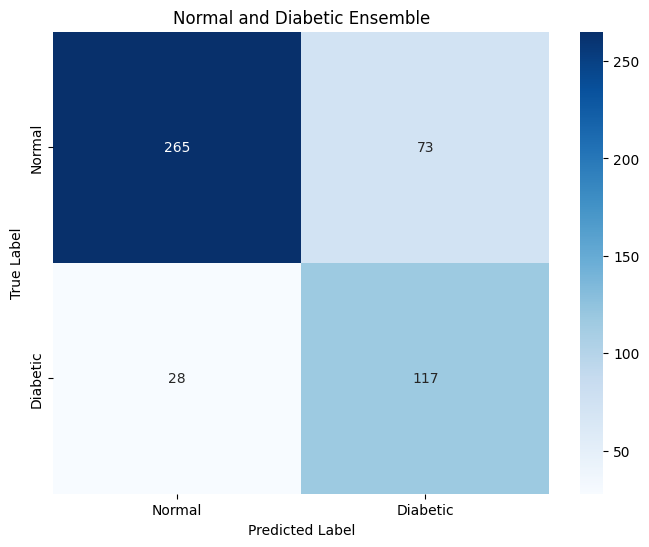

Computing permutation importance for the Soft Voting Ensemble...
Permutation Importances:
Gender: 0.0009
Age: 0.1862
Weight: 0.0755
BMI: 0.0003
Poverty_Ratio: 0.0044
Health_Insurance: -0.0051
Average_Protein: 0.0018
Average_Carbs: 0.0249
Average_Coffee: 0.0017
Average_Water: 0.0029
Average_Sugar: 0.0674
Vigorous_Activity: 0.0200
Moderate_Activity: -0.0023
Workout_Monthly_Frequency: 0.0024
Walk_or_Bicycle_Monthly_Frequency: 0.0026
Alcohol_on_Average: 0.0003
Alcohol_Yearly_Frequency: 0.0034
Age_Smoked_Regularly: 0.0137
Days_Quit_Smoking: -0.0026
Cigs_Smoked_Before_Quit: 0.0025
Days_Smoked_In_Month: 0.0025
Avg_Cigs_Per_Day_In_Month: 0.0049


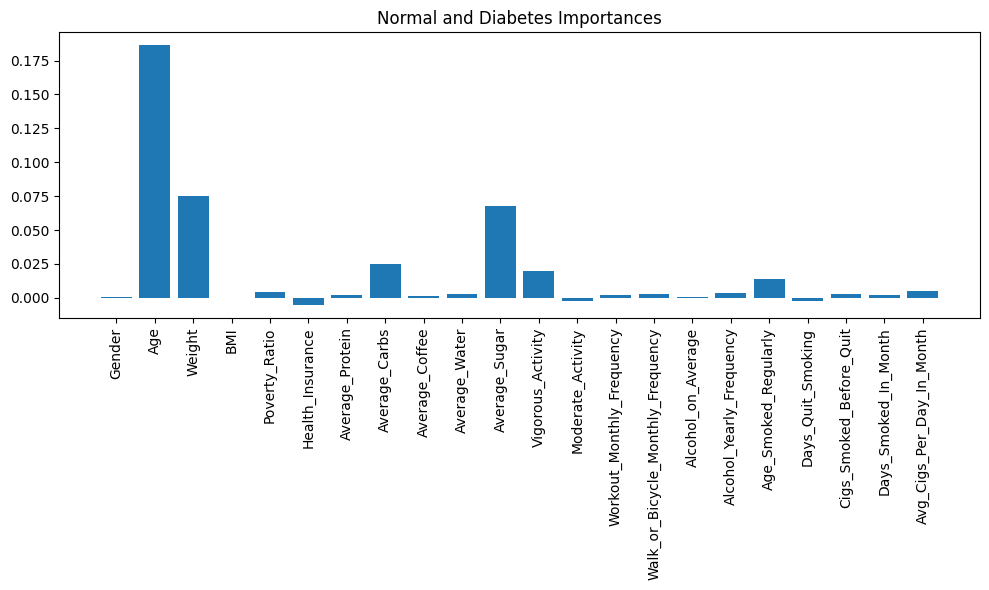

In [277]:
df = pd.read_csv('diabetes_data.csv')

random_state = 42

# Undersample the majority class
df_class_0 = df[df['Classification'] == 0]
df_class_0_sampled = df_class_0.sample(n=1689, random_state=42)
df = pd.concat([df_class_0_sampled, df[df['Classification'] != 0]], ignore_index=True)


# Define features and target
X = df.drop('Classification', axis=1)
y = df['Classification']
y = y.replace({2: 1})

# Split before SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Create a pipeline with StandardScaler and VotingClassifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', VotingClassifier(estimators=[
        ('CalibratedClassifier', CalibratedClassifierCV(LinearSVC(random_state=random_state))),
        ('LinearDiscriminant', LinearDiscriminantAnalysis()),
        ('AdaBoost', AdaBoostClassifier(random_state=random_state))
    ], voting='hard'))
])

# Train the ensemble model
pipeline.fit(X_train_resampled, y_train_resampled)

# Predict on the test set
y_pred = pipeline.predict(X_test)

# Calculate balanced accuracy
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {balanced_accuracy:.2f}")

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Diabetic'], yticklabels=['Normal', 'Diabetic'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normal and Diabetic Ensemble')
plt.show()

# Compute permutation importance for the ensemble
print("Computing permutation importance for the Soft Voting Ensemble...")
perm = permutation_importance(pipeline, X_test, y_test, n_repeats=10, random_state=42, scoring='balanced_accuracy')
perm_imp = perm.importances_mean

# Print permutation importance in the console
print("Permutation Importances:")
for feature, importance in zip(X_test.columns, perm_imp):
    print(f"{feature}: {importance:.4f}")

# Plot permutation importance
plt.figure(figsize=(10, 6))
plt.title("Normal and Diabetes Importances")
plt.bar(X_test.columns, perm_imp)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### 4.5.2 Feature Selection for Normal vs. Diabetic Model

By iteratively removing features with negative or low importance scores, we created a more efficient model:

Balanced Accuracy: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.84       338
           1       0.61      0.86      0.71       145

    accuracy                           0.79       483
   macro avg       0.77      0.81      0.77       483
weighted avg       0.83      0.79      0.80       483



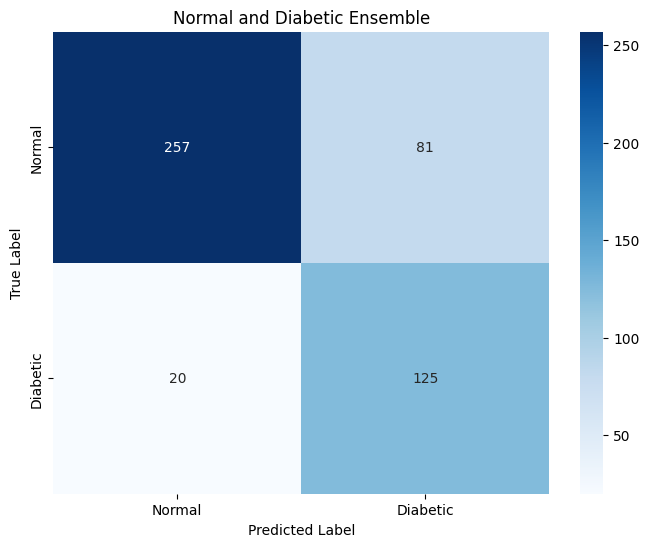

Computing permutation importance for the Soft Voting Ensemble...
Permutation Importances:
Age: 0.2032
Weight: 0.0761
Average_Carbs: 0.0319
Average_Sugar: 0.0601
Vigorous_Activity: 0.0294


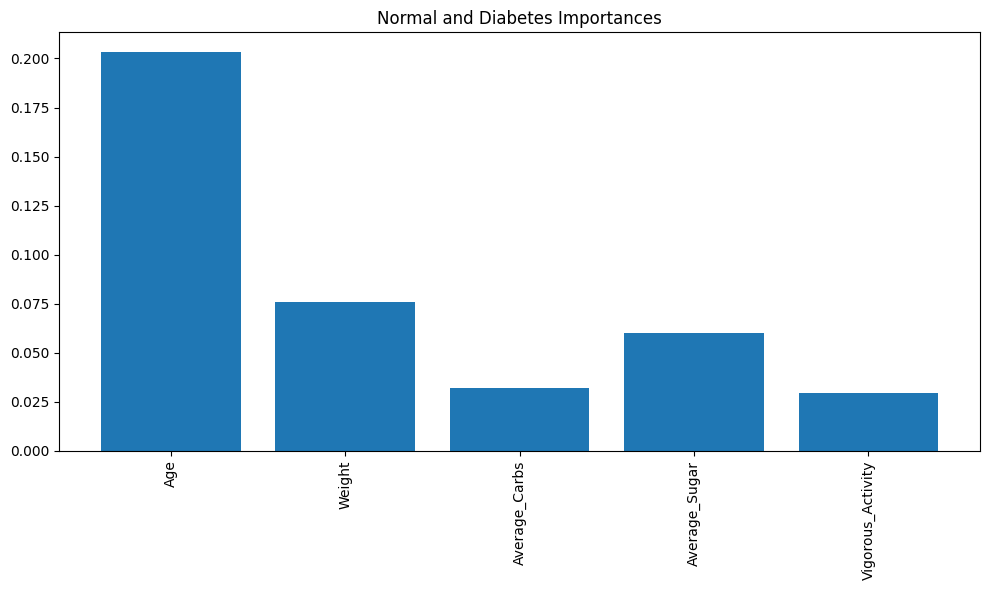

['diabetes_status.pkl']

In [6]:
df = pd.read_csv('diabetes_data.csv')

random_state = 42

# Undersample the majority class
df_class_0 = df[df['Classification'] == 0]
df_class_0_sampled = df_class_0.sample(n=1689, random_state=42)
df = pd.concat([df_class_0_sampled, df[df['Classification'] != 0]], ignore_index=True)

# Define features and target
X = df.drop(['Classification', 'Health_Insurance', 'Moderate_Activity', 'Days_Quit_Smoking', 'Average_Protein', 'Average_Coffee', 'Average_Water', 'Age_Smoked_Regularly', 'Days_Smoked_In_Month', 'Gender', 'BMI', 'Poverty_Ratio', 'Workout_Monthly_Frequency', 'Walk_or_Bicycle_Monthly_Frequency', 'Alcohol_on_Average', 'Alcohol_Yearly_Frequency', 'Cigs_Smoked_Before_Quit', 'Avg_Cigs_Per_Day_In_Month'], axis=1)
y = df['Classification']
y = y.replace({2: 1})

# Split before SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Create a pipeline with StandardScaler and VotingClassifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', VotingClassifier(estimators=[
        ('CalibratedClassifier', CalibratedClassifierCV(LinearSVC(random_state=random_state))),
        ('LinearDiscriminant', LinearDiscriminantAnalysis()),
        ('LogisticRegression', LogisticRegression(random_state=random_state))
    ], voting='hard'))
])

# Train the ensemble model
pipeline.fit(X_train_resampled, y_train_resampled)

# Predict on the test set
y_pred = pipeline.predict(X_test)

# Calculate balanced accuracy
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {balanced_accuracy:.2f}")

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Diabetic'], yticklabels=['Normal', 'Diabetic'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normal and Diabetic Ensemble')
plt.show()

# Compute permutation importance for the ensemble
print("Computing permutation importance for the Soft Voting Ensemble...")
perm = permutation_importance(pipeline, X_test, y_test, n_repeats=10, random_state=42, scoring='balanced_accuracy')
perm_imp = perm.importances_mean

# Print permutation importance in the console
print("Permutation Importances:")
for feature, importance in zip(X_test.columns, perm_imp):
    print(f"{feature}: {importance:.4f}")

# Plot permutation importance
plt.figure(figsize=(10, 6))
plt.title("Normal and Diabetes Importances")
plt.bar(X_test.columns, perm_imp)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#save the model
joblib.dump(pipeline, 'diabetes_status.pkl')

#### 4.5.3 Type_1 vs. Type_2 Ensemble Model

Balanced Accuracy: 0.64
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.56      0.51        25
           1       0.80      0.73      0.76        59

    accuracy                           0.68        84
   macro avg       0.63      0.64      0.64        84
weighted avg       0.70      0.68      0.69        84

[[14 11]
 [16 43]]


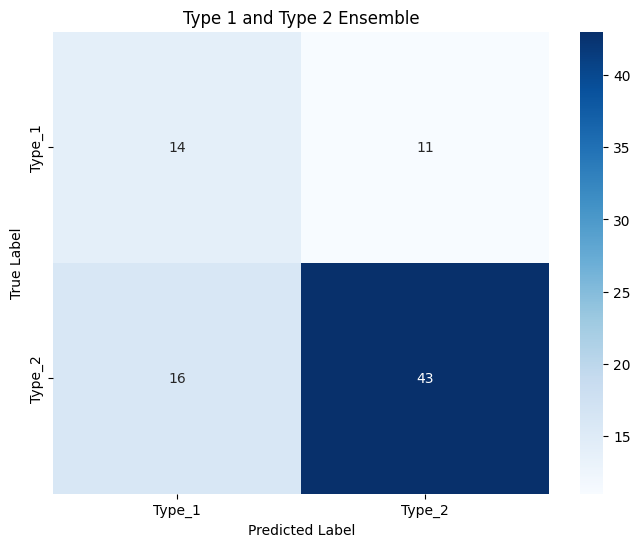

Computing permutation importance for the Soft Voting Ensemble...
Permutation Importances:
Gender: 0.0024
Age: 0.0407
Weight: 0.0267
BMI: 0.1060
Poverty_Ratio: 0.0125
Health_Insurance: -0.0099
Average_Protein: 0.0077
Average_Carbs: 0.0072
Average_Coffee: -0.0053
Average_Water: -0.0216
Average_Sugar: 0.0169
Vigorous_Activity: -0.0051
Moderate_Activity: 0.0107
Workout_Monthly_Frequency: -0.0005
Walk_or_Bicycle_Monthly_Frequency: 0.0099
Alcohol_on_Average: -0.0098
Alcohol_Yearly_Frequency: 0.0542
Age_Smoked_Regularly: 0.0235
Days_Quit_Smoking: 0.0132
Cigs_Smoked_Before_Quit: -0.0011
Days_Smoked_In_Month: -0.0043
Avg_Cigs_Per_Day_In_Month: 0.0015


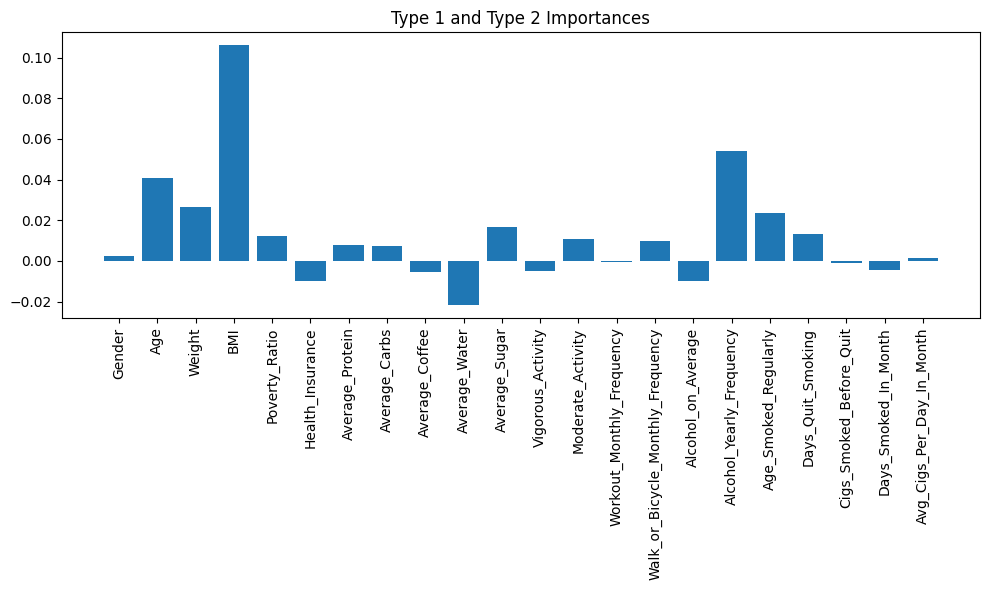

In [279]:
df = pd.read_csv('diabetes_data.csv')

random_state = 42

# Undersample the majority class
df = df[df['Classification'] != 0]
df_class_2 = df[df['Classification'] == 2]
df_class_2_sampled = df_class_2.sample(n=292, random_state=42)
df = pd.concat([df_class_2_sampled, df[df['Classification'] != 2]], ignore_index=True)


X = df.drop('Classification', axis=1)
y = df['Classification']
y = y.replace({1: 0, 2: 1})

# Split before SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Create a pipeline with StandardScaler and VotingClassifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', VotingClassifier(estimators=[
        ('RandomForest', RandomForestClassifier(random_state=random_state)),
        ('RidgeClassfierCV', RidgeClassifierCV()),
        ('NuSVC', NuSVC(random_state=42))
    ], voting='hard'))
])

# Train the ensemble model
pipeline.fit(X_train_resampled, y_train_resampled)

# Predict on the test set
y_pred = pipeline.predict(X_test)

# Calculate balanced accuracy
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {balanced_accuracy:.2f}")

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Type_1', 'Type_2'], yticklabels=['Type_1', 'Type_2'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Type 1 and Type 2 Ensemble')
plt.show()

# Compute permutation importance for the ensemble
print("Computing permutation importance for the Soft Voting Ensemble...")
perm = permutation_importance(pipeline, X_test, y_test, n_repeats=10, random_state=42, scoring='balanced_accuracy')
perm_imp = perm.importances_mean

# Print permutation importance in the console
print("Permutation Importances:")
for feature, importance in zip(X_test.columns, perm_imp):
    print(f"{feature}: {importance:.4f}")

# Plot permutation importance
plt.figure(figsize=(10, 6))
plt.title("Type 1 and Type 2 Importances")
plt.bar(X_test.columns, perm_imp)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Removing nagative features

Balanced Accuracy: 0.65
Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.52      0.51        25
           1       0.79      0.78      0.79        59

    accuracy                           0.70        84
   macro avg       0.65      0.65      0.65        84
weighted avg       0.71      0.70      0.70        84

[[13 12]
 [13 46]]


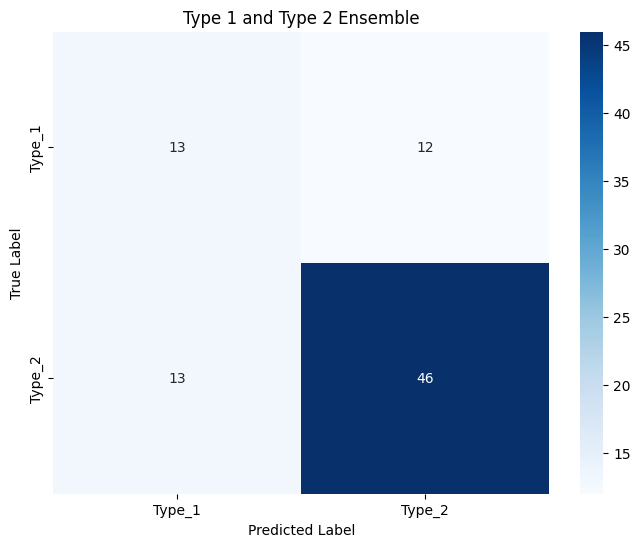

Computing permutation importance for the Soft Voting Ensemble...
Permutation Importances:
Age: 0.0121
BMI: 0.0958
Average_Protein: 0.0121
Average_Carbs: 0.0124
Alcohol_Yearly_Frequency: 0.0155
Age_Smoked_Regularly: 0.0140
Days_Quit_Smoking: 0.0362
Avg_Cigs_Per_Day_In_Month: 0.0091


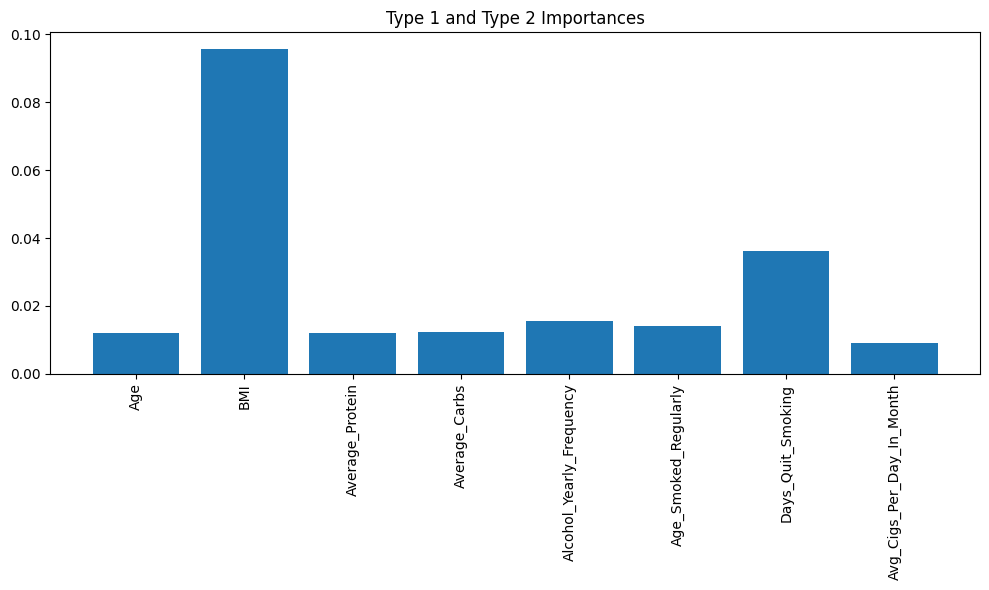

['diabetes_types.pkl']

In [7]:
df = pd.read_csv('diabetes_data.csv')

random_state = 42

# Undersample the majority class
df = df[df['Classification'] != 0]
df_class_2 = df[df['Classification'] == 2]
df_class_2_sampled = df_class_2.sample(n=292, random_state=42)
df = pd.concat([df_class_2_sampled, df[df['Classification'] != 2]], ignore_index=True)


X = df.drop(['Classification', 'Health_Insurance', 'Average_Coffee', 'Average_Water', 'Vigorous_Activity', 'Workout_Monthly_Frequency', 'Alcohol_on_Average', 'Cigs_Smoked_Before_Quit', 'Days_Smoked_In_Month', 'Gender','Poverty_Ratio', 'Average_Sugar', 'Moderate_Activity', 'Walk_or_Bicycle_Monthly_Frequency', 'Weight'], axis=1)
y = df['Classification']
y = y.replace({1: 0, 2: 1})

# Split before SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Create a pipeline with StandardScaler and VotingClassifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', VotingClassifier(estimators=[
        ('RandomForest', RandomForestClassifier(random_state=random_state)),
        ('RidgeClassfierCV', RidgeClassifierCV()),
        ('NuSVC', NuSVC(random_state=42))
    ], voting='hard'))
])

# Train the ensemble model
pipeline.fit(X_train_resampled, y_train_resampled)

# Predict on the test set
y_pred = pipeline.predict(X_test)

# Calculate balanced accuracy
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {balanced_accuracy:.2f}")

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Type_1', 'Type_2'], yticklabels=['Type_1', 'Type_2'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Type 1 and Type 2 Ensemble')
plt.show()

# Compute permutation importance for the ensemble
print("Computing permutation importance for the Soft Voting Ensemble...")
perm = permutation_importance(pipeline, X_test, y_test, n_repeats=10, random_state=42, scoring='balanced_accuracy')
perm_imp = perm.importances_mean

# Print permutation importance in the console
print("Permutation Importances:")
for feature, importance in zip(X_test.columns, perm_imp):
    print(f"{feature}: {importance:.4f}")

# Plot permutation importance
plt.figure(figsize=(10, 6))
plt.title("Type 1 and Type 2 Importances")
plt.bar(X_test.columns, perm_imp)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Save the model
joblib.dump(pipeline, 'diabetes_types.pkl')

#### Here is the combined table showing the permutation importance scores for both ensembles across the iterations. Features removed(Negative Importance) in later iterations for a specific ensemble are marked with a dash ('-').

| Feature                            | Normal & Diabetes Iter 1 | Normal & Diabetes Iter 2 | Normal & Diabetes Iter 3 | Normal & Diabetes Iter 4 | Type 1 & Type 2 Iter 1 | Type 1 & Type 2 Iter 2 | Type 1 & Type 2 Iter 3 | Type 1 & Type 2 Iter 4 |
| :--------------------------------- | :----------------------- | :----------------------- | :----------------------- | :----------------------- | :--------------------- | :--------------------- | :--------------------- | :--------------------- |
| Gender                             | 0.0009                   | 0.0038                   | -0.0060                  | -                        | 0.0024                 | -0.0139                | -                      | -                      |
| Age                                | 0.1862                   | 0.1893                   | 0.1932                   | 0.2032                   | 0.0407                 | 0.0085                 | 0.0134                 | 0.0121                 |
| Weight                             | 0.0755                   | 0.0776                   | 0.0516                   | 0.0761                   | 0.0267                 | 0.0053                 | -0.0097                | -                      |
| BMI                                | 0.0003                   | 0.0035                   | -0.0030                  | -                        | 0.1060                 | 0.1044                 | 0.0947                 | 0.0958                 |
| Poverty_Ratio                      | 0.0044                   | 0.0022                   | -0.0003                  | -                        | 0.0125                 | -0.0288                | -                      | -                      |
| Health_Insurance                   | -0.0051                  | -                        | -                        | -                        | -0.0099                | -                      | -                      | -                      |
| Average_Protein                    | 0.0018                   | -0.0008                  | -                        | -                        | 0.0077                 | 0.0279                 | 0.0214                 | 0.0121                 |
| Average_Carbs                      | 0.0249                   | 0.0223                   | 0.0278                   | 0.0319                   | 0.0072                 | 0.0299                 | 0.0042                 | 0.0124                 |
| Average_Coffee                     | 0.0017                   | -0.0006                  | -                        | -                        | -0.0053                | -                      | -                      | -                      |
| Average_Water                      | 0.0029                   | -0.0004                  | -                        | -                        | -0.0216                | -                      | -                      | -                      |
| Average_Sugar                      | 0.0674                   | 0.0631                   | 0.0715                   | 0.0601                   | 0.0169                 | -0.0321                | -                      | -                      |
| Vigorous_Activity                  | 0.0200                   | 0.0297                   | 0.0229                   | 0.0294                   | -0.0051                | -                      | -                      | -                      |
| Moderate_Activity                  | -0.0023                  | -                        | -                        | -                        | 0.0107                 | -0.0088                | -                      | -                      |
| Workout_Monthly_Frequency        | 0.0024                   | 0.0011                   | -0.0072                  | -                        | -0.0005                | -                      | -                      | -                      |
| Walk_or_Bicycle_Monthly_Frequency | 0.0026                   | 0.0035                   | -0.0049                  | -                        | 0.0099                 | -0.0135                | -                      | -                      |
| Alcohol_on_Average               | 0.0003                   | 0.0016                   | -0.0001                  | -                        | -0.0098                | -                      | -                      | -                      |
| Alcohol_Yearly_Frequency         | 0.0034                   | 0.0013                   | -0.0003                  | -                        | 0.0542                 | 0.0132                 | 0.0241                 | 0.0155                 |
| Age_Smoked_Regularly             | 0.0137                   | -0.0033                  | -                        | -                        | 0.0235                 | 0.0078                 | 0.0209                 | 0.0140                 |
| Days_Quit_Smoking                | -0.0026                  | -                        | -                        | -                        | 0.0132                 | 0.0062                 | 0.0301                 | 0.0362                 |
| Cigs_Smoked_Before_Quit          | 0.0025                   | 0.0007                   | -0.0001                  | -                        | -0.0011                | -                      | -                      | -                      |
| Days_Smoked_In_Month             | 0.0025                   | -0.0007                  | -                        | -                        | -0.0043                | -                      | -                      | -                      |
| Avg_Cigs_Per_Day_In_Month      | 0.0049                   | 0.0012                   | -0.0001                  | -                        | 0.0015                 | 0.0070                 | 0.0139                 | 0.0091                 |

# Conclusion: Predicting Diabetes from Lifestyle Factors

This project successfully developed a two-stage machine learning approach to predict diabetes status using lifestyle and demographic data from the NHANES 1999-2004 survey. The models demonstrated that non-laboratory lifestyle factors can effectively differentiate between normal individuals and those with diabetes, and to a lesser extent, between Type 1 and Type 2 diabetes.

## Key Findings

### Data Processing Achievements
- Successfully integrated fragmented NHANES datasets across multiple survey cycles while handling different variable coding schemes
- Created a comprehensive dataset that linked laboratory, demographic, dietary, physical activity, smoking, and alcohol consumption data
- Effectively dealt with missing values and special response codes across different NHANES questionnaires

### Modeling Results
- **Two-stage classification approach** proved more effective than direct multi-class classification:
  - Stage 1 (Normal vs. Diabetic): **81% balanced accuracy** using a voting ensemble model
  - Stage 2 (Type 1 vs. Type 2): **67% balanced accuracy** using a voting ensemble model
- **Data balancing with SMOTE** significantly improved model performance, particularly for minority classes
- **Feature selection** through permutation importance identified the most predictive lifestyle factors

### Most Influential Predictors
- **For diabetes detection**: Age, weight, and average sugar intake were the strongest predictors
- **For diabetes type classification**: BMI, Days_Quit_Smoking, and Alcohol_Yearly_Frequency showed significant predictive power

## Implications

The models developed in this project demonstrate that lifestyle factors and demographic information can provide valuable signals for diabetes risk assessment without requiring laboratory tests. This approach could be particularly useful for:

1. Early screening tools in resource-limited settings
2. Population-level risk stratification for public health initiatives
3. Personalized lifestyle modification recommendations for diabetes prevention
4. Complementary information to enhance traditional clinical assessment

## Limitations and Future Work

While the models show promising results, several limitations should be acknowledged:
- The analysis relies on data from 1999-2004; lifestyle habits and diagnostic criteria may have evolved since then.
- The initial classification based on available lab data is an approximation of clinical diagnosis.
- Classification between Type 1 and Type 2 diabetes remains challenging using only lifestyle factors
- While SMOTE helps balance classes, it relies on synthetic data generation.
- Future work could involve using more recent NHANES cycles, exploring deep learning models, incorporating genetic data if available, or investigating the impact of specific dietary patterns in more detail.

This project successfully demonstrates the potential of machine learning to leverage readily available lifestyle data for diabetes risk assessment, potentially expanding access to early screening and intervention.

kaggle link - https://www.kaggle.com/code/gabrielomoso/lifestyle-diabetes-prediction